#                                 Regresi - 2D - california_housing

# Load Data

In [19]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import os

In [20]:

file_name = "california_housing"
root_folder = f'regresi/one-d/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Scaler

In [21]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'MedInc', 
    'HouseAge', 
    'AveRooms',
    'AveBedrms',
    'Population', 
    'AveOccup',
    'Latitude',
    'Longitude',
    #'MedHouseVal',
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'MedInc' saved as scaler_MedInc.pkl
✅ Scaler for 'HouseAge' saved as scaler_HouseAge.pkl
✅ Scaler for 'AveRooms' saved as scaler_AveRooms.pkl
✅ Scaler for 'AveBedrms' saved as scaler_AveBedrms.pkl
✅ Scaler for 'Population' saved as scaler_Population.pkl
✅ Scaler for 'AveOccup' saved as scaler_AveOccup.pkl
✅ Scaler for 'Latitude' saved as scaler_Latitude.pkl
✅ Scaler for 'Longitude' saved as scaler_Longitude.pkl

All individual scalers saved successfully!


In [22]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422


#### Select Kolom To Trian

In [23]:
col_target = 'MedHouseVal'
cols = [
    'MedInc', 
    'HouseAge', 
    'AveRooms',
    'AveBedrms',
    'Population', 
    'AveOccup',
    'Latitude',
    'Longitude',
    #------------------------
    col_target
]
df = df[cols].copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,4.526
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,3.585
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,3.521
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,3.413
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,3.422


# Data Load To Train

#### select Future to traian

In [24]:
# Misal df sudah berisi semua data
# Pisahkan fitur dan target
feature_1_cols = ['MedInc','HouseAge', 'AveRooms', 'AveBedrms']
feature_2_cols = ['Population','AveOccup', 'Latitude', 'Longitude']

target_cols  = col_target


#### Split data

In [25]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Pisahkan train-test (stratify opsional jika masih punya kolom 'diabetes_stage')
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


#### DataLoader

In [26]:
from data_set import Regression2DDataset

# Buat dataset dengan class kamu
train_dataset = Regression2DDataset(X_train, feature_1_cols,feature_2_cols, target_cols, normalize=False)
test_dataset  = Regression2DDataset(X_test,  feature_1_cols,feature_2_cols, target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Cek contoh batch
for X1,X2, y in train_loader:
    print("X1 shape:", X1.shape)
    print("X2 shape:", X2.shape)
    print("y shape:", y.shape)
    print(X1[:3])  # contoh fitur
    print(X2[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X1 shape: torch.Size([32, 4])
X2 shape: torch.Size([32, 4])
y shape: torch.Size([32, 1])
tensor([[0.0252, 1.0000, 0.0204, 0.0186],
        [0.1808, 0.7451, 0.0262, 0.0213],
        [0.3035, 0.2157, 0.0406, 0.0212]])
tensor([[0.0263, 0.0024, 0.1679, 0.7052],
        [0.0419, 0.0025, 0.1860, 0.5896],
        [0.0435, 0.0017, 0.6567, 0.3098]])
tensor([[0.8750],
        [1.5350],
        [2.0370]])


# Config

In [27]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "feature_1_cols" : feature_1_cols,
    "feature_2_cols" : feature_2_cols,
    "input_1_dim"    : len(test_dataset.X1[0]),
    "input_2_dim"    : len(test_dataset.X2[0]),
    "hidden_1_dims"  : [ 2],
    "hidden_2_dims"  : [ 3],
    "combine_dims"   : [3],
    "output_dim"     : len(test_dataset.y[0]),
    "dropout"        : 0.0,
    "activation"     : "relu",
    "early_stop_patience" : 10,
    "col_target"     : col_target
})
config

Config(activation=relu, col_target=MedHouseVal, combine_dims=[3], dropout=0.0, early_stop_patience=10, feature_1_cols=['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms'], feature_2_cols=['Population', 'AveOccup', 'Latitude', 'Longitude'], hidden_1_dims=[2], hidden_2_dims=[3], input_1_dim=4, input_2_dim=4, output_dim=1)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [28]:
from class_lib import Model2DPure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model
model = Model2DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    combined_dims= config.combine_dims,
    output_dim=config.output_dim, 
    dropout=config.dropout, 
    activation=config.activation
).to(device)

#Criterion
criterion = nn.MSELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

#### Visualisasi Model

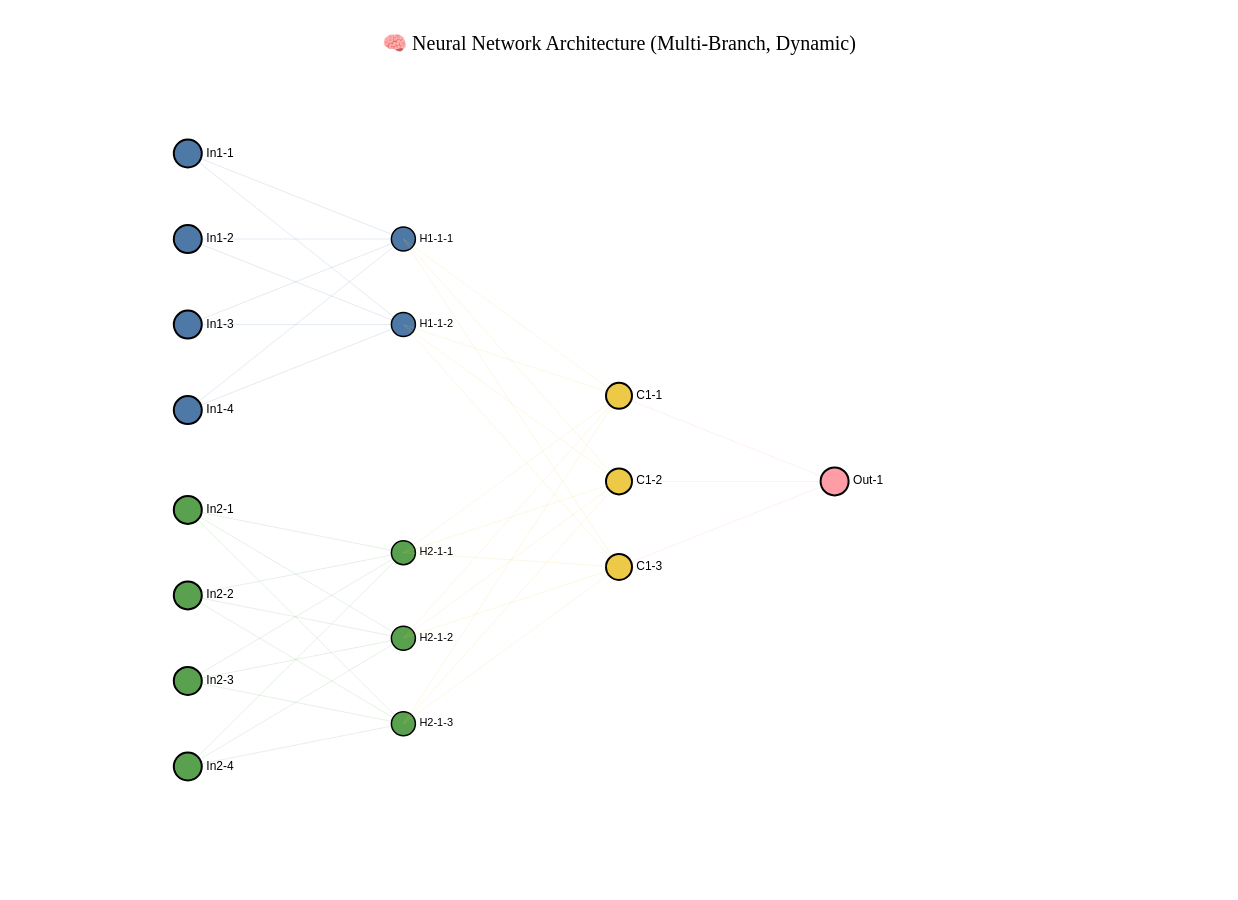

In [29]:
from visualization import plot_dynamic_multi_input_network
plot_dynamic_multi_input_network(
    input_dims=[config.input_1_dim, config.input_2_dim],
    hidden_dims_per_branch=[
        config.hidden_1_dims,
        config.hidden_2_dims
    ],
    combined_dims=config.combine_dims,
    output_dim=config.output_dim,
    figsize=(1000, 900)
)

# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1572.22it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  1.4474 │  1.3146 │
│ MAE    │  0.9352 │  0.9036 │
│ RMSE   │  1.2031 │  1.1465 │
│ R2     │ -0.0828 │ -0.0032 │
└────────┴─────────┴─────────┘

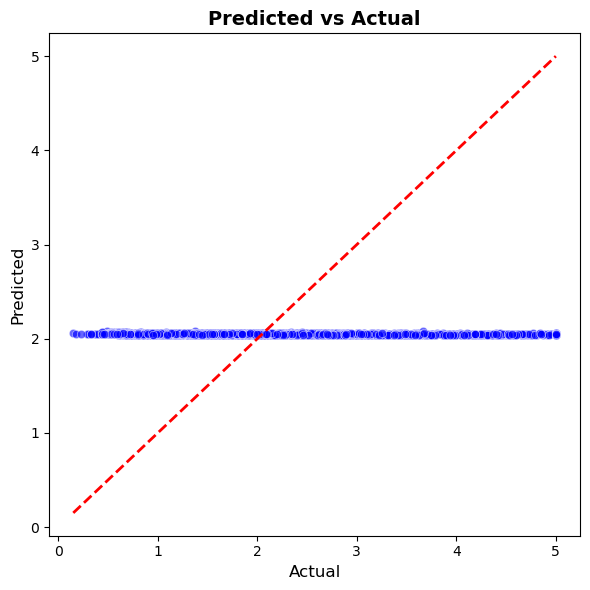


Epoch     1
Train_cost  = 1.4474 | Test_cost  = 1.3146 | Train_score = -0.0828 | Test_score = -0.0032 |
==> EarlyStop patience =  1 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1705.06it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  1.3410 │  1.3128 │
│ MAE    │  0.9151 │  0.9031 │
│ RMSE   │  1.1580 │  1.1458 │
│ R2     │ -0.0032 │ -0.0019 │
└────────┴─────────┴─────────┘

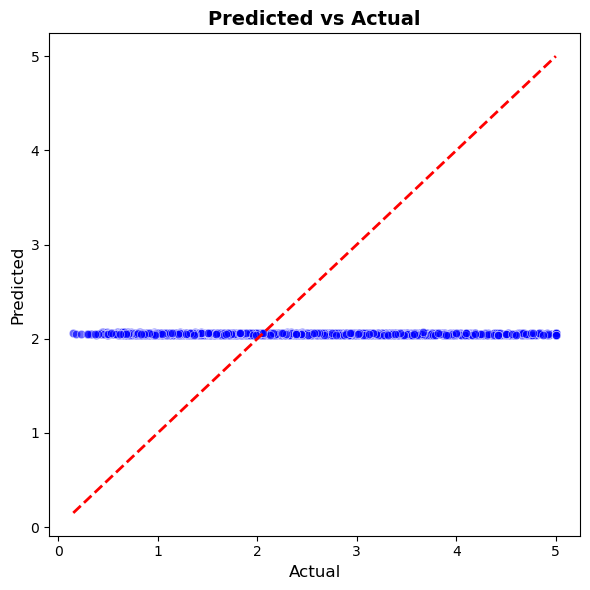


Epoch     2
Train_cost  = 1.3410 | Test_cost  = 1.3128 | Train_score = -0.0032 | Test_score = -0.0019 |
==> EarlyStop patience =  2 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1606.98it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  1.3393 │  1.3150 │
│ MAE    │  0.9139 │  0.9149 │
│ RMSE   │  1.1573 │  1.1467 │
│ R2     │ -0.0019 │ -0.0035 │
└────────┴─────────┴─────────┘

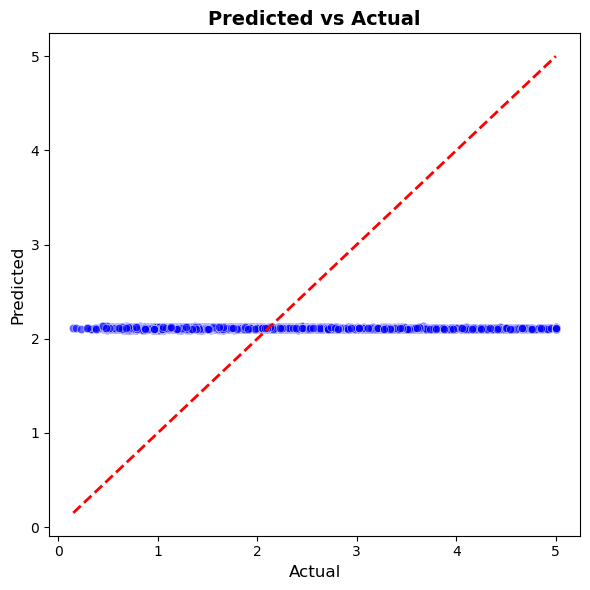


Epoch     3
Train_cost  = 1.3393 | Test_cost  = 1.3150 | Train_score = -0.0019 | Test_score = -0.0035 |
==> EarlyStop patience =  3 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1494.68it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  1.3386 │  1.3166 │
│ MAE    │  0.9148 │  0.9189 │
│ RMSE   │  1.1570 │  1.1475 │
│ R2     │ -0.0014 │ -0.0048 │
└────────┴─────────┴─────────┘

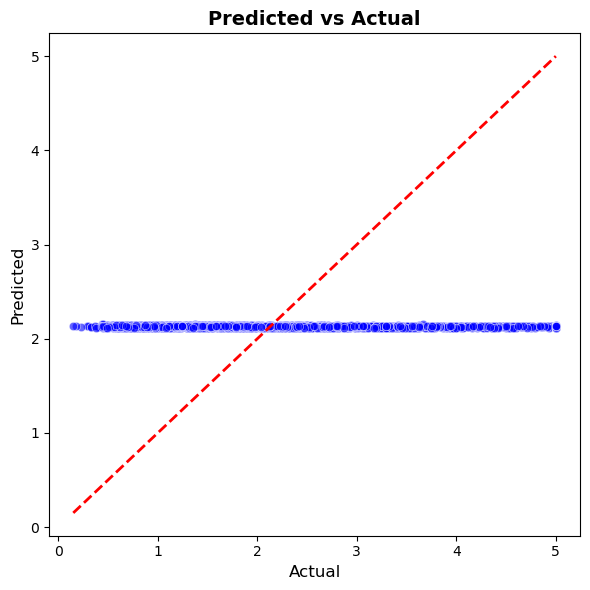


Epoch     4
Train_cost  = 1.3386 | Test_cost  = 1.3166 | Train_score = -0.0014 | Test_score = -0.0048 |
==> EarlyStop patience =  4 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1654.65it/s]


     Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Metric ┃   Train ┃    Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ LOSS   │  1.3378 │  1.3106 │
│ MAE    │  0.9151 │  0.8998 │
│ RMSE   │  1.1566 │  1.1448 │
│ R2     │ -0.0008 │ -0.0001 │
└────────┴─────────┴─────────┘

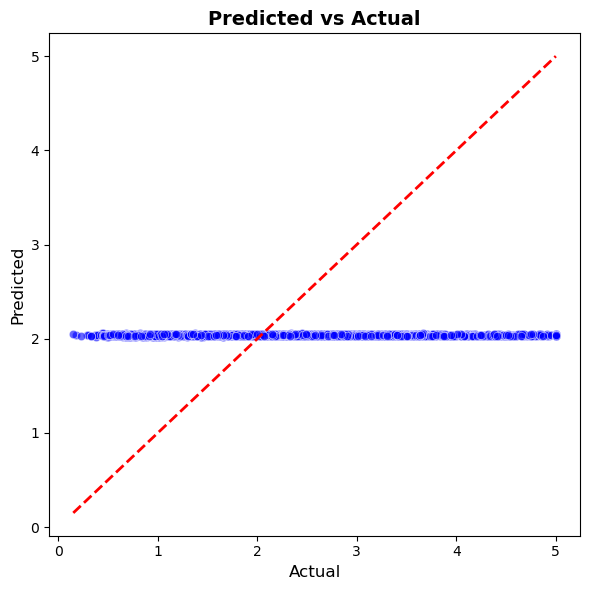


Epoch     5
Train_cost  = 1.3378 | Test_cost  = 1.3106 | Train_score = -0.0008 | Test_score = -0.0001 |
==> EarlyStop patience =  5 | Best test_score: 0.0000


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1606.47it/s]


    Summary (Regression)     
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃   Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ LOSS   │  1.3378 │ 1.3097 │
│ MAE    │  0.9142 │ 0.9015 │
│ RMSE   │  1.1566 │ 1.1444 │
│ R2     │ -0.0008 │ 0.0005 │
└────────┴─────────┴────────┘

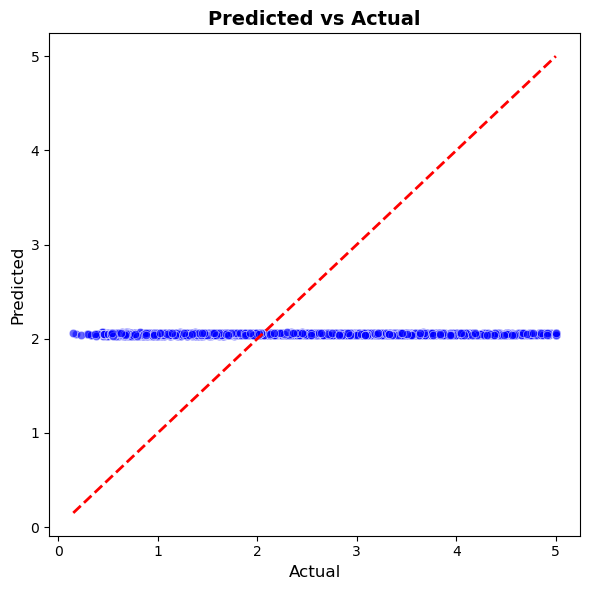


Epoch     6
Train_cost  = 1.3378 | Test_cost  = 1.3097 | Train_score = -0.0008 | Test_score = 0.0005 |


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1676.32it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.3366 │ 1.3097 │
│ MAE    │ 0.9136 │ 0.9079 │
│ RMSE   │ 1.1561 │ 1.1444 │
│ R2     │ 0.0001 │ 0.0006 │
└────────┴────────┴────────┘

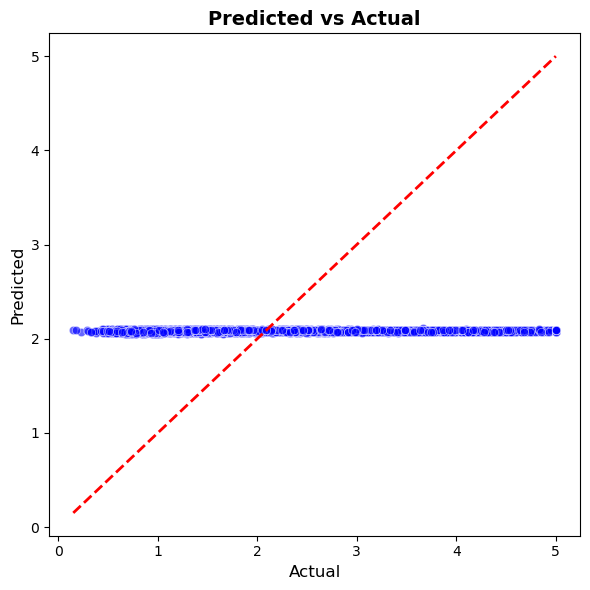


Epoch     7
Train_cost  = 1.3366 | Test_cost  = 1.3097 | Train_score = 0.0001 | Test_score = 0.0006 |


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1486.12it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.3342 │ 1.3057 │
│ MAE    │ 0.9135 │ 0.9066 │
│ RMSE   │ 1.1551 │ 1.1427 │
│ R2     │ 0.0019 │ 0.0036 │
└────────┴────────┴────────┘

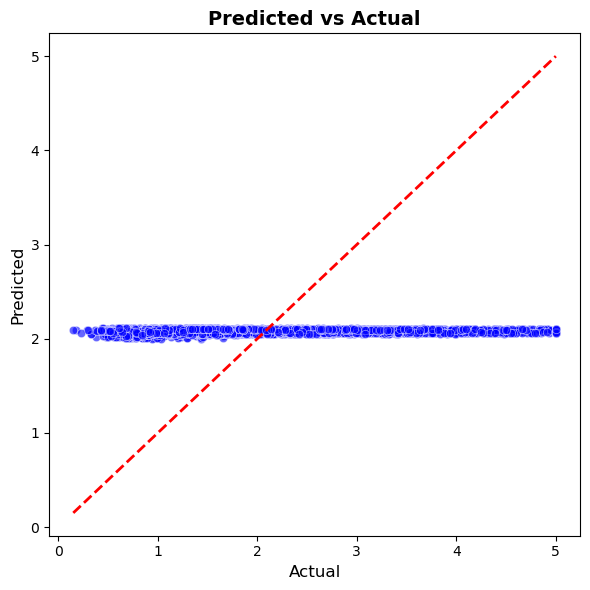


Epoch     8
Train_cost  = 1.3342 | Test_cost  = 1.3057 | Train_score = 0.0019 | Test_score = 0.0036 |


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1482.09it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.3309 │ 1.3020 │
│ MAE    │ 0.9122 │ 0.9070 │
│ RMSE   │ 1.1537 │ 1.1410 │
│ R2     │ 0.0044 │ 0.0064 │
└────────┴────────┴────────┘

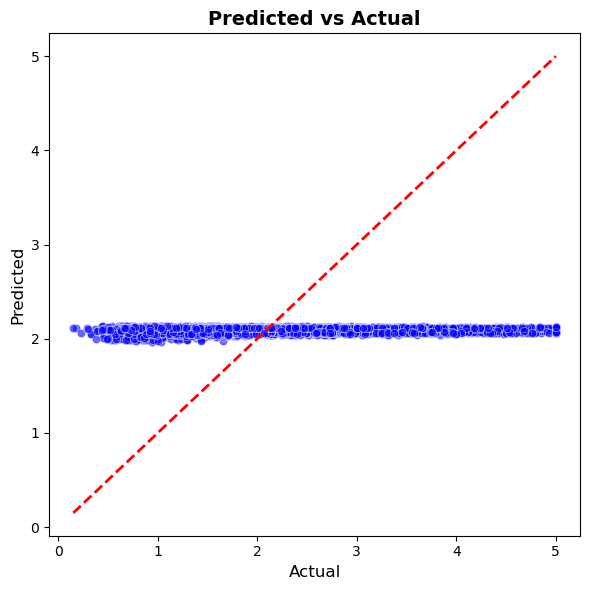


Epoch     9
Train_cost  = 1.3309 | Test_cost  = 1.3020 | Train_score = 0.0044 | Test_score = 0.0064 |


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1487.50it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.3230 │ 1.2888 │
│ MAE    │ 0.9094 │ 0.8982 │
│ RMSE   │ 1.1502 │ 1.1353 │
│ R2     │ 0.0103 │ 0.0165 │
└────────┴────────┴────────┘

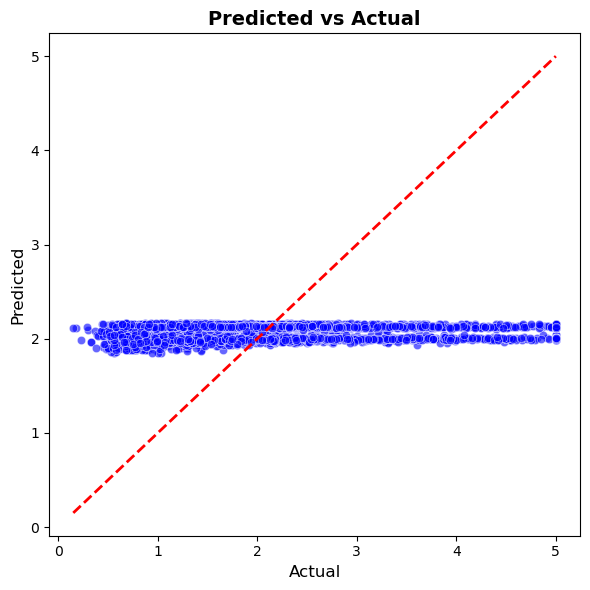


Epoch    10
Train_cost  = 1.3230 | Test_cost  = 1.2888 | Train_score = 0.0103 | Test_score = 0.0165 |


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1667.35it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.3106 │ 1.2732 │
│ MAE    │ 0.9054 │ 0.8932 │
│ RMSE   │ 1.1448 │ 1.1284 │
│ R2     │ 0.0196 │ 0.0284 │
└────────┴────────┴────────┘

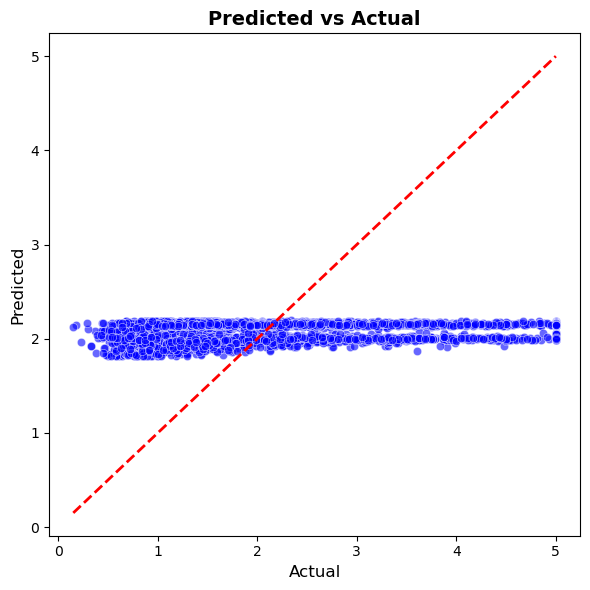


Epoch    11
Train_cost  = 1.3106 | Test_cost  = 1.2732 | Train_score = 0.0196 | Test_score = 0.0284 |


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1688.49it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.2897 │ 1.2457 │
│ MAE    │ 0.8977 │ 0.8886 │
│ RMSE   │ 1.1357 │ 1.1161 │
│ R2     │ 0.0352 │ 0.0494 │
└────────┴────────┴────────┘

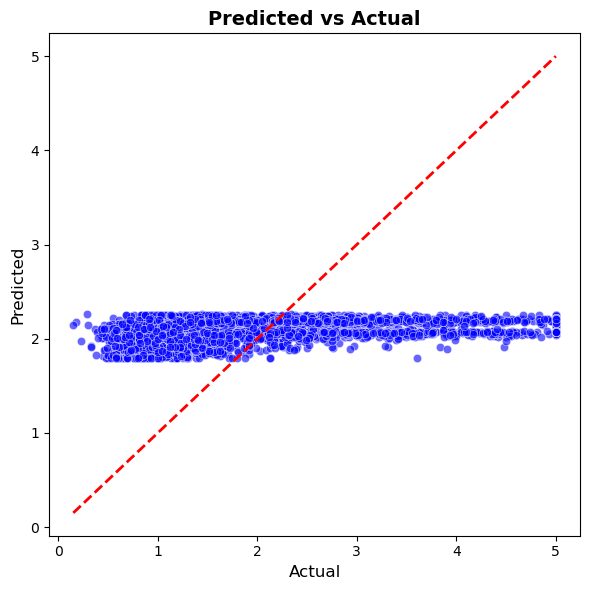


Epoch    12
Train_cost  = 1.2897 | Test_cost  = 1.2457 | Train_score = 0.0352 | Test_score = 0.0494 |


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1605.27it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.2440 │ 1.1751 │
│ MAE    │ 0.8787 │ 0.8508 │
│ RMSE   │ 1.1154 │ 1.0840 │
│ R2     │ 0.0694 │ 0.1033 │
└────────┴────────┴────────┘

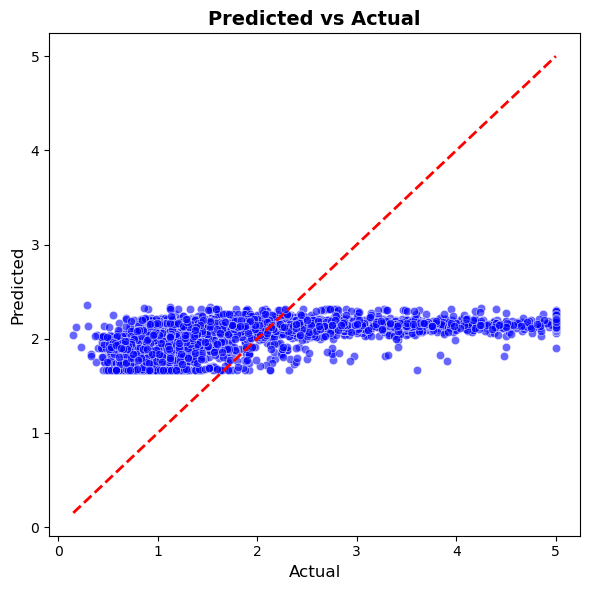


Epoch    13
Train_cost  = 1.2440 | Test_cost  = 1.1751 | Train_score = 0.0694 | Test_score = 0.1033 |


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1689.03it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.1525 │ 1.0553 │
│ MAE    │ 0.8382 │ 0.7998 │
│ RMSE   │ 1.0735 │ 1.0273 │
│ R2     │ 0.1379 │ 0.1947 │
└────────┴────────┴────────┘

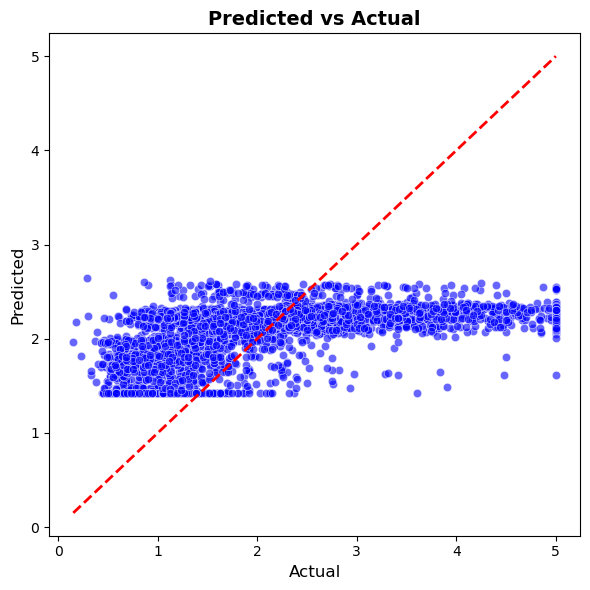


Epoch    14
Train_cost  = 1.1525 | Test_cost  = 1.0553 | Train_score = 0.1379 | Test_score = 0.1947 |


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1674.69it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 1.0420 │ 0.9567 │
│ MAE    │ 0.7840 │ 0.7585 │
│ RMSE   │ 1.0208 │ 0.9781 │
│ R2     │ 0.2205 │ 0.2699 │
└────────┴────────┴────────┘

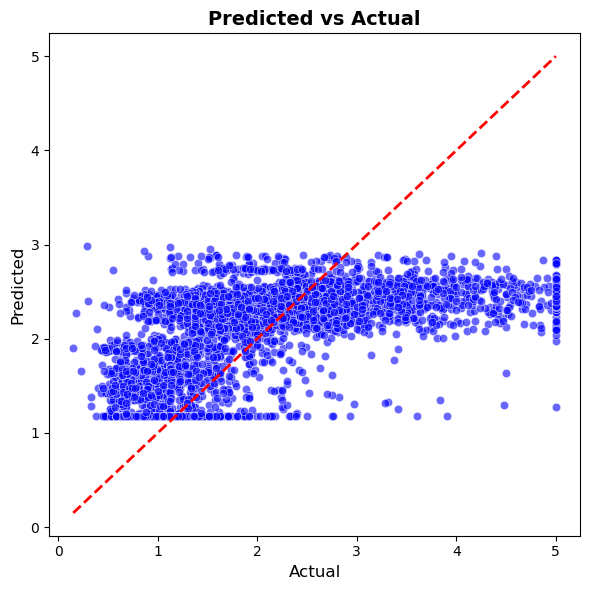


Epoch    15
Train_cost  = 1.0420 | Test_cost  = 0.9567 | Train_score = 0.2205 | Test_score = 0.2699 |


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1720.89it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9767 │ 0.9136 │
│ MAE    │ 0.7510 │ 0.7198 │
│ RMSE   │ 0.9883 │ 0.9558 │
│ R2     │ 0.2694 │ 0.3028 │
└────────┴────────┴────────┘

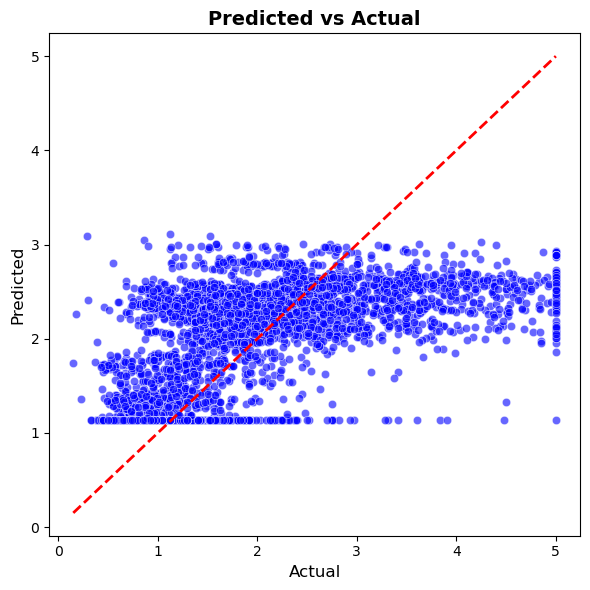


Epoch    16
Train_cost  = 0.9767 | Test_cost  = 0.9136 | Train_score = 0.2694 | Test_score = 0.3028 |


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1720.80it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9616 │ 0.9155 │
│ MAE    │ 0.7418 │ 0.6974 │
│ RMSE   │ 0.9806 │ 0.9568 │
│ R2     │ 0.2806 │ 0.3013 │
└────────┴────────┴────────┘

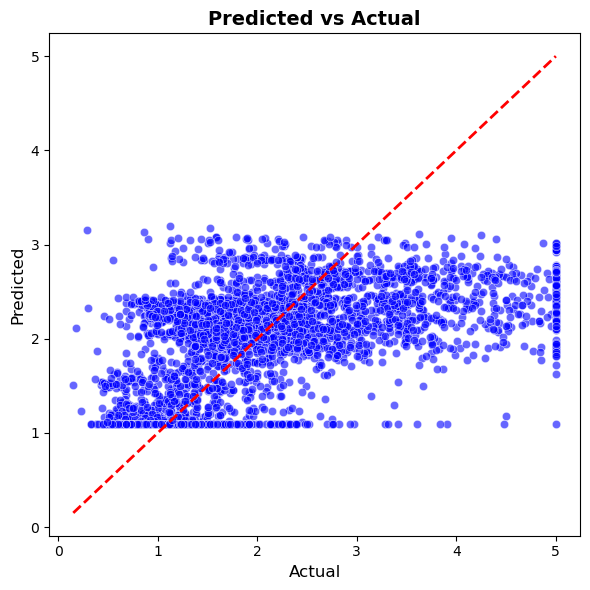


Epoch    17
Train_cost  = 0.9616 | Test_cost  = 0.9155 | Train_score = 0.2806 | Test_score = 0.3013 |
==> EarlyStop patience =  1 | Best test_score: 0.3028


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1735.32it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9638 │ 0.9019 │
│ MAE    │ 0.7414 │ 0.6998 │
│ RMSE   │ 0.9817 │ 0.9497 │
│ R2     │ 0.2790 │ 0.3117 │
└────────┴────────┴────────┘

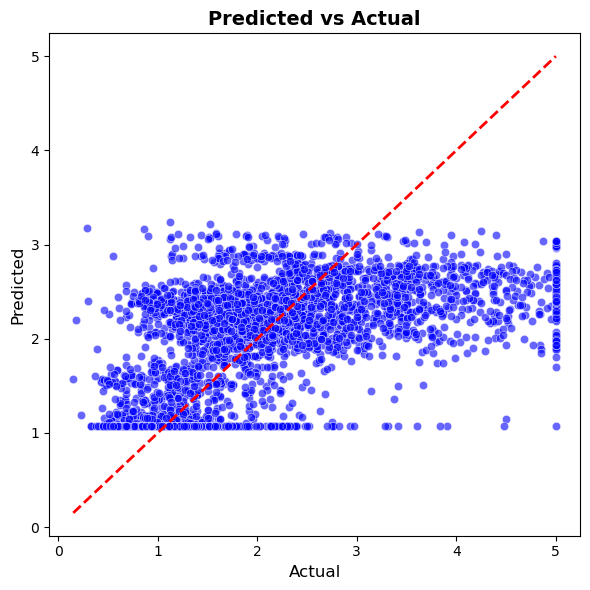


Epoch    18
Train_cost  = 0.9638 | Test_cost  = 0.9019 | Train_score = 0.2790 | Test_score = 0.3117 |


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1596.19it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9551 │ 0.9691 │
│ MAE    │ 0.7377 │ 0.7869 │
│ RMSE   │ 0.9773 │ 0.9845 │
│ R2     │ 0.2855 │ 0.2604 │
└────────┴────────┴────────┘

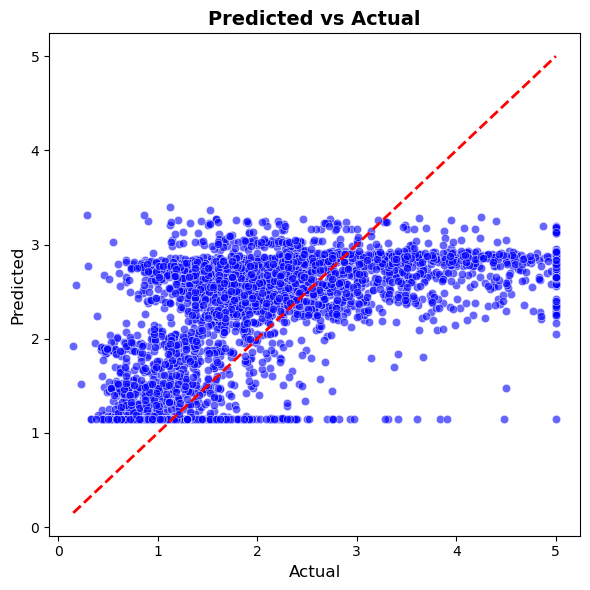


Epoch    19
Train_cost  = 0.9551 | Test_cost  = 0.9691 | Train_score = 0.2855 | Test_score = 0.2604 |
==> EarlyStop patience =  1 | Best test_score: 0.3117


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1728.02it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9582 │ 0.8985 │
│ MAE    │ 0.7381 │ 0.7192 │
│ RMSE   │ 0.9789 │ 0.9479 │
│ R2     │ 0.2832 │ 0.3144 │
└────────┴────────┴────────┘

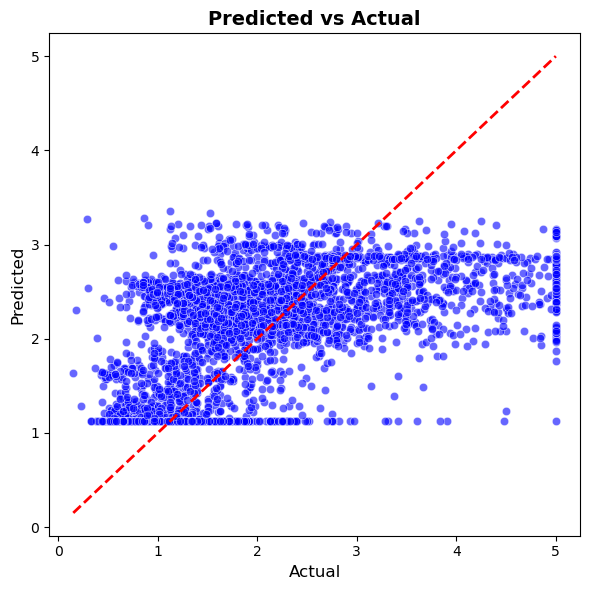


Epoch    20
Train_cost  = 0.9582 | Test_cost  = 0.8985 | Train_score = 0.2832 | Test_score = 0.3144 |


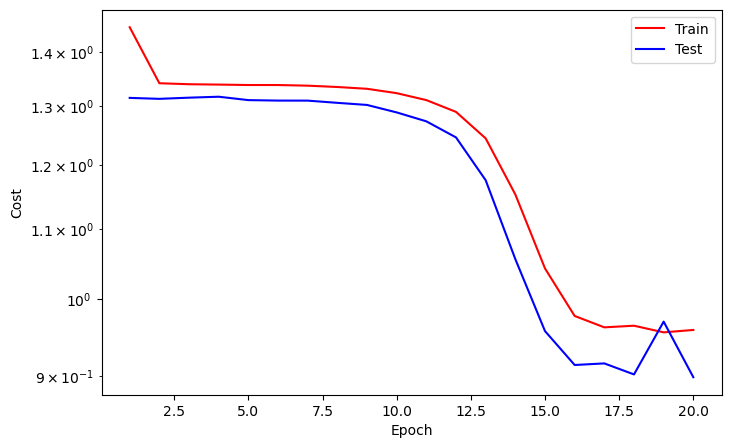

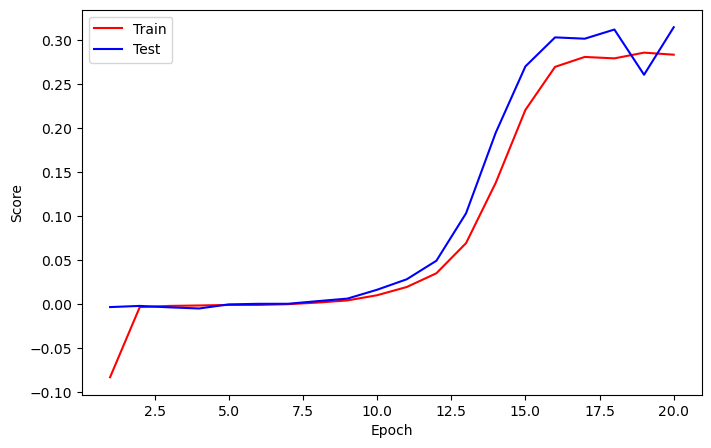

─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1631.20it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9584 │ 0.9065 │
│ MAE    │ 0.7389 │ 0.7298 │
│ RMSE   │ 0.9790 │ 0.9521 │
│ R2     │ 0.2831 │ 0.3082 │
└────────┴────────┴────────┘

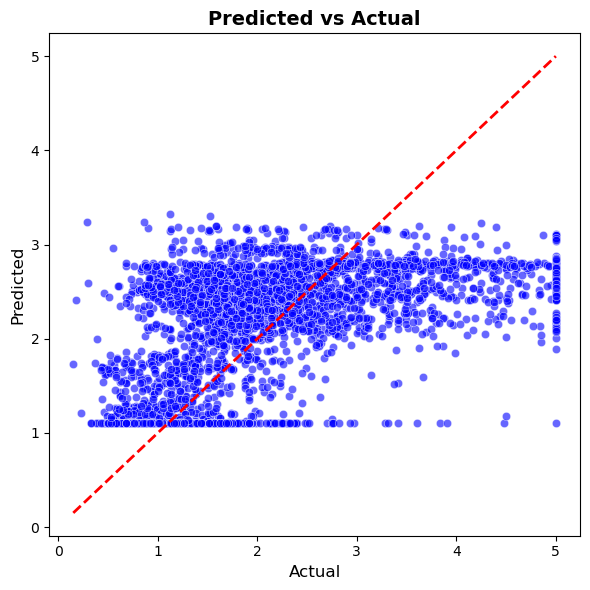


Epoch    21
Train_cost  = 0.9584 | Test_cost  = 0.9065 | Train_score = 0.2831 | Test_score = 0.3082 |
==> EarlyStop patience =  1 | Best test_score: 0.3144


─────────────────────────────────────────────────── 🚀 EPOCH 22 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1604.33it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9491 │ 0.9013 │
│ MAE    │ 0.7347 │ 0.7248 │
│ RMSE   │ 0.9742 │ 0.9494 │
│ R2     │ 0.2900 │ 0.3122 │
└────────┴────────┴────────┘

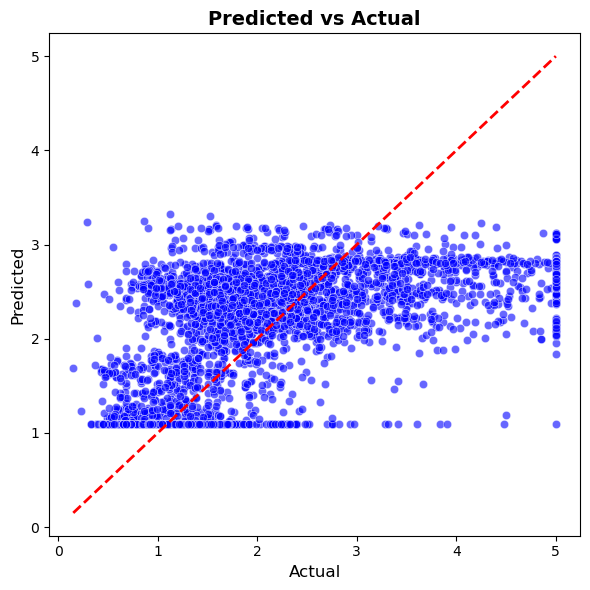


Epoch    22
Train_cost  = 0.9491 | Test_cost  = 0.9013 | Train_score = 0.2900 | Test_score = 0.3122 |
==> EarlyStop patience =  2 | Best test_score: 0.3144


─────────────────────────────────────────────────── 🚀 EPOCH 23 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1655.09it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9530 │ 0.8946 │
│ MAE    │ 0.7347 │ 0.7135 │
│ RMSE   │ 0.9762 │ 0.9458 │
│ R2     │ 0.2871 │ 0.3173 │
└────────┴────────┴────────┘

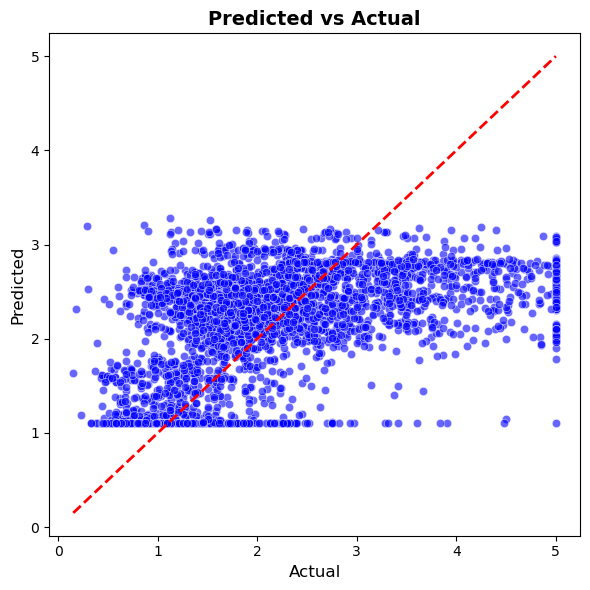


Epoch    23
Train_cost  = 0.9530 | Test_cost  = 0.8946 | Train_score = 0.2871 | Test_score = 0.3173 |


─────────────────────────────────────────────────── 🚀 EPOCH 24 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1662.04it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9491 │ 0.9328 │
│ MAE    │ 0.7336 │ 0.6893 │
│ RMSE   │ 0.9742 │ 0.9658 │
│ R2     │ 0.2900 │ 0.2882 │
└────────┴────────┴────────┘

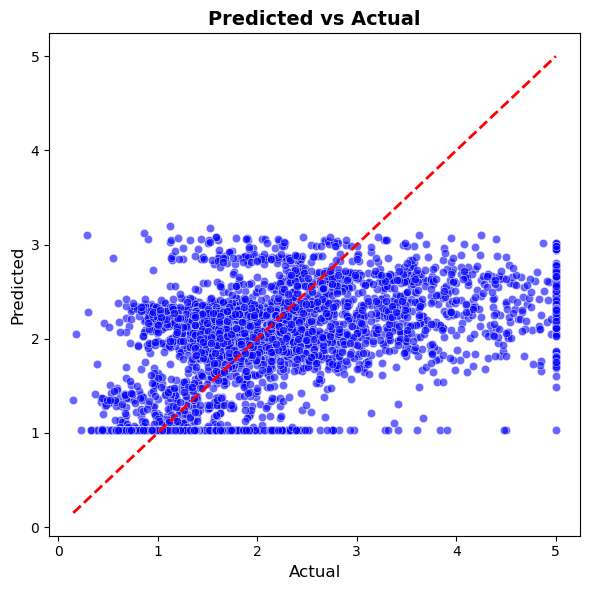


Epoch    24
Train_cost  = 0.9491 | Test_cost  = 0.9328 | Train_score = 0.2900 | Test_score = 0.2882 |
==> EarlyStop patience =  1 | Best test_score: 0.3173


─────────────────────────────────────────────────── 🚀 EPOCH 25 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1668.76it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9500 │ 0.8937 │
│ MAE    │ 0.7344 │ 0.7060 │
│ RMSE   │ 0.9747 │ 0.9454 │
│ R2     │ 0.2893 │ 0.3180 │
└────────┴────────┴────────┘

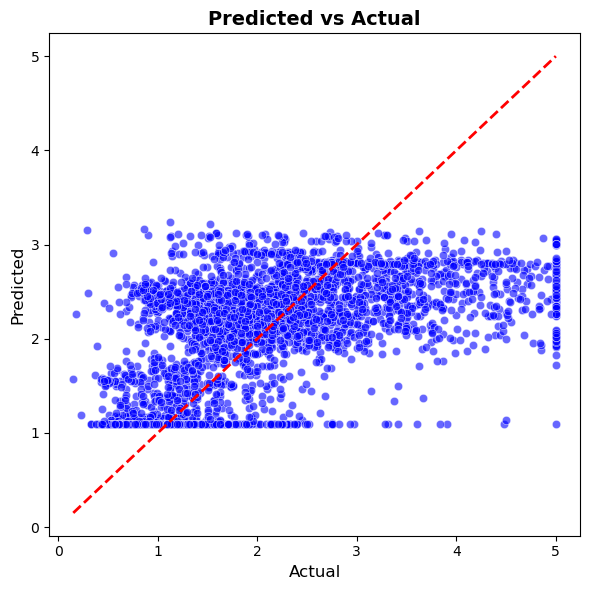


Epoch    25
Train_cost  = 0.9500 | Test_cost  = 0.8937 | Train_score = 0.2893 | Test_score = 0.3180 |


─────────────────────────────────────────────────── 🚀 EPOCH 26 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1673.31it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9442 │ 0.9074 │
│ MAE    │ 0.7318 │ 0.7317 │
│ RMSE   │ 0.9717 │ 0.9526 │
│ R2     │ 0.2937 │ 0.3075 │
└────────┴────────┴────────┘

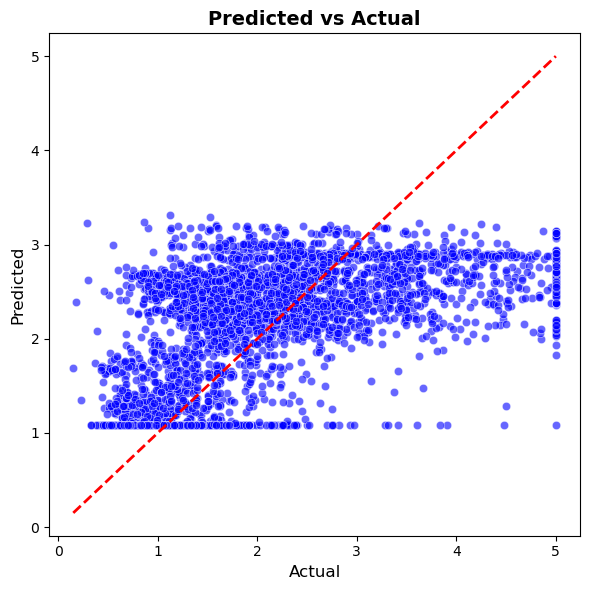


Epoch    26
Train_cost  = 0.9442 | Test_cost  = 0.9074 | Train_score = 0.2937 | Test_score = 0.3075 |
==> EarlyStop patience =  1 | Best test_score: 0.3180


─────────────────────────────────────────────────── 🚀 EPOCH 27 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1740.97it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9496 │ 0.8971 │
│ MAE    │ 0.7338 │ 0.7010 │
│ RMSE   │ 0.9745 │ 0.9472 │
│ R2     │ 0.2896 │ 0.3154 │
└────────┴────────┴────────┘

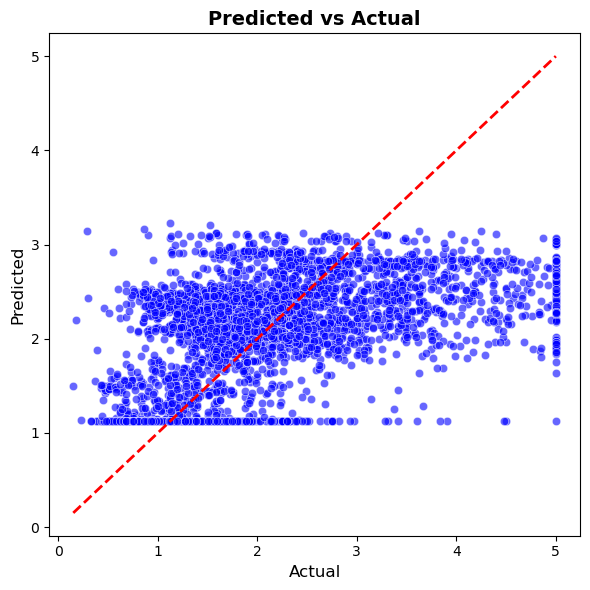


Epoch    27
Train_cost  = 0.9496 | Test_cost  = 0.8971 | Train_score = 0.2896 | Test_score = 0.3154 |
==> EarlyStop patience =  2 | Best test_score: 0.3180


─────────────────────────────────────────────────── 🚀 EPOCH 28 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1727.90it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9471 │ 0.9481 │
│ MAE    │ 0.7338 │ 0.7722 │
│ RMSE   │ 0.9732 │ 0.9737 │
│ R2     │ 0.2915 │ 0.2765 │
└────────┴────────┴────────┘

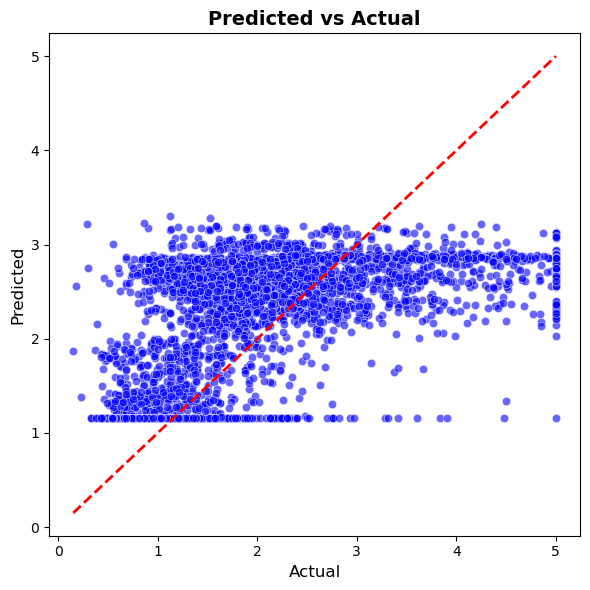


Epoch    28
Train_cost  = 0.9471 | Test_cost  = 0.9481 | Train_score = 0.2915 | Test_score = 0.2765 |
==> EarlyStop patience =  3 | Best test_score: 0.3180


─────────────────────────────────────────────────── 🚀 EPOCH 29 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1682.25it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9500 │ 0.9203 │
│ MAE    │ 0.7343 │ 0.7485 │
│ RMSE   │ 0.9747 │ 0.9593 │
│ R2     │ 0.2893 │ 0.2977 │
└────────┴────────┴────────┘

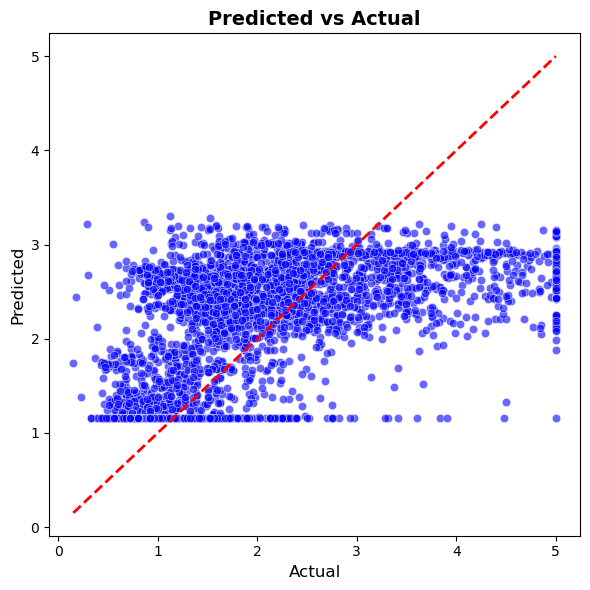


Epoch    29
Train_cost  = 0.9500 | Test_cost  = 0.9203 | Train_score = 0.2893 | Test_score = 0.2977 |
==> EarlyStop patience =  4 | Best test_score: 0.3180


─────────────────────────────────────────────────── 🚀 EPOCH 30 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1706.73it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9508 │ 0.9434 │
│ MAE    │ 0.7343 │ 0.6921 │
│ RMSE   │ 0.9751 │ 0.9713 │
│ R2     │ 0.2887 │ 0.2801 │
└────────┴────────┴────────┘

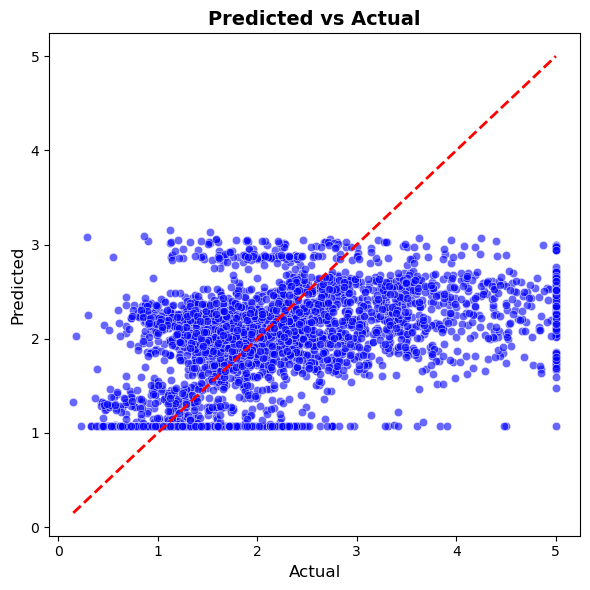


Epoch    30
Train_cost  = 0.9508 | Test_cost  = 0.9434 | Train_score = 0.2887 | Test_score = 0.2801 |
==> EarlyStop patience =  5 | Best test_score: 0.3180


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1784.02it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9451 │ 0.8928 │
│ MAE    │ 0.7332 │ 0.7095 │
│ RMSE   │ 0.9722 │ 0.9449 │
│ R2     │ 0.2930 │ 0.3187 │
└────────┴────────┴────────┘

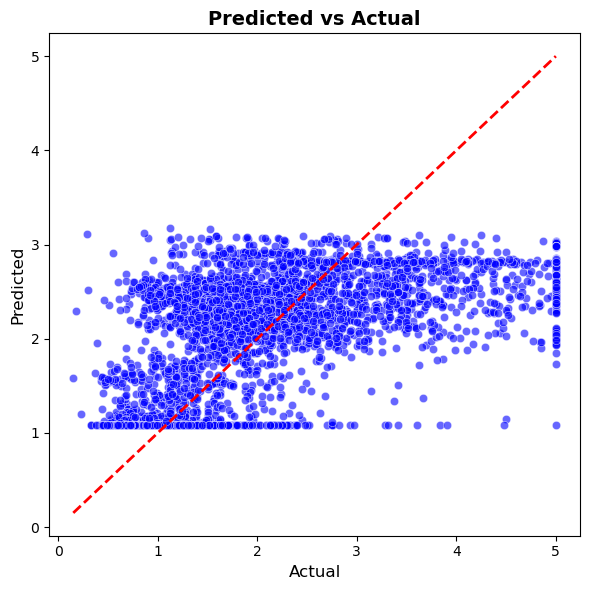


Epoch    31
Train_cost  = 0.9451 | Test_cost  = 0.8928 | Train_score = 0.2930 | Test_score = 0.3187 |


─────────────────────────────────────────────────── 🚀 EPOCH 32 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1606.23it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9462 │ 0.9074 │
│ MAE    │ 0.7334 │ 0.6931 │
│ RMSE   │ 0.9727 │ 0.9526 │
│ R2     │ 0.2922 │ 0.3075 │
└────────┴────────┴────────┘

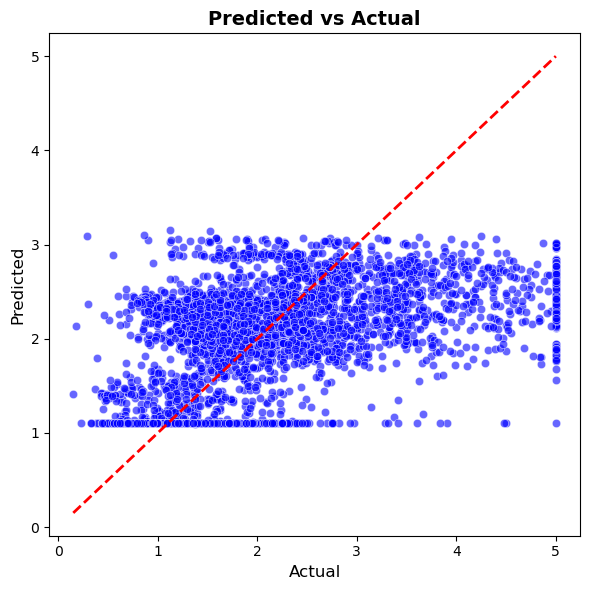


Epoch    32
Train_cost  = 0.9462 | Test_cost  = 0.9074 | Train_score = 0.2922 | Test_score = 0.3075 |
==> EarlyStop patience =  1 | Best test_score: 0.3187


─────────────────────────────────────────────────── 🚀 EPOCH 33 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1651.36it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9446 │ 0.9541 │
│ MAE    │ 0.7322 │ 0.7747 │
│ RMSE   │ 0.9719 │ 0.9768 │
│ R2     │ 0.2934 │ 0.2719 │
└────────┴────────┴────────┘

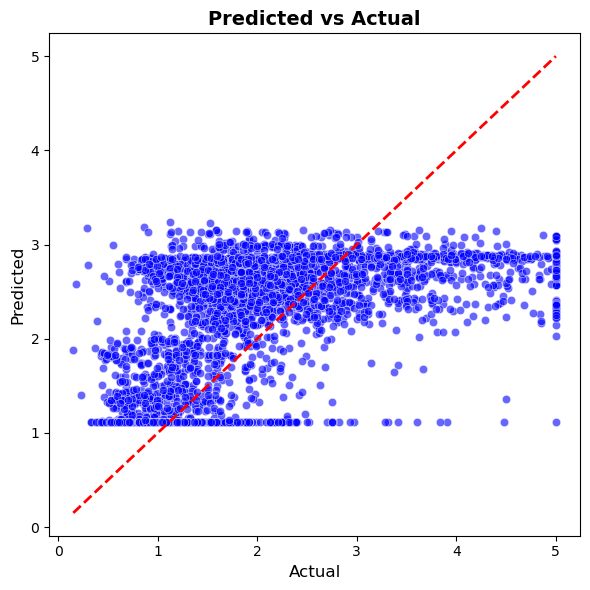


Epoch    33
Train_cost  = 0.9446 | Test_cost  = 0.9541 | Train_score = 0.2934 | Test_score = 0.2719 |
==> EarlyStop patience =  2 | Best test_score: 0.3187


─────────────────────────────────────────────────── 🚀 EPOCH 34 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1640.04it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9429 │ 0.8930 │
│ MAE    │ 0.7317 │ 0.7181 │
│ RMSE   │ 0.9710 │ 0.9450 │
│ R2     │ 0.2946 │ 0.3185 │
└────────┴────────┴────────┘

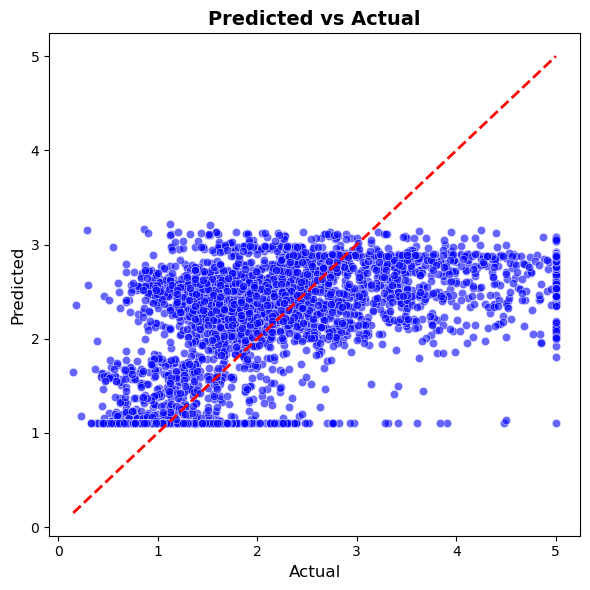


Epoch    34
Train_cost  = 0.9429 | Test_cost  = 0.8930 | Train_score = 0.2946 | Test_score = 0.3185 |
==> EarlyStop patience =  3 | Best test_score: 0.3187


─────────────────────────────────────────────────── 🚀 EPOCH 35 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1705.09it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9454 │ 0.8985 │
│ MAE    │ 0.7324 │ 0.6978 │
│ RMSE   │ 0.9723 │ 0.9479 │
│ R2     │ 0.2928 │ 0.3143 │
└────────┴────────┴────────┘

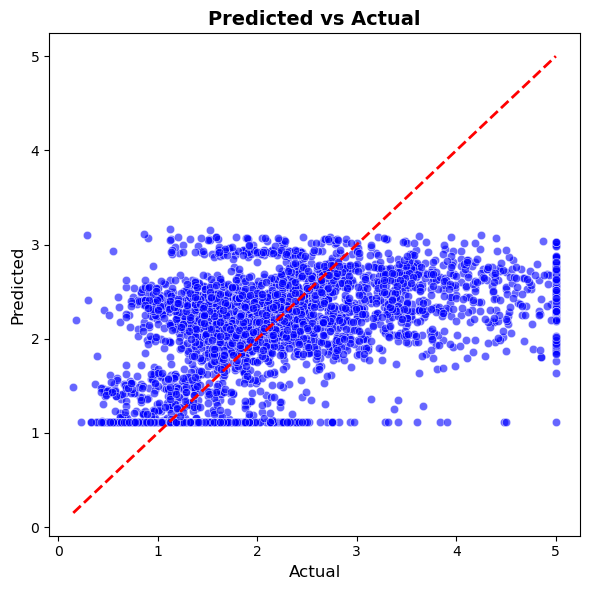


Epoch    35
Train_cost  = 0.9454 | Test_cost  = 0.8985 | Train_score = 0.2928 | Test_score = 0.3143 |
==> EarlyStop patience =  4 | Best test_score: 0.3187


─────────────────────────────────────────────────── 🚀 EPOCH 36 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1723.20it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9477 │ 0.9198 │
│ MAE    │ 0.7339 │ 0.7479 │
│ RMSE   │ 0.9735 │ 0.9591 │
│ R2     │ 0.2911 │ 0.2981 │
└────────┴────────┴────────┘

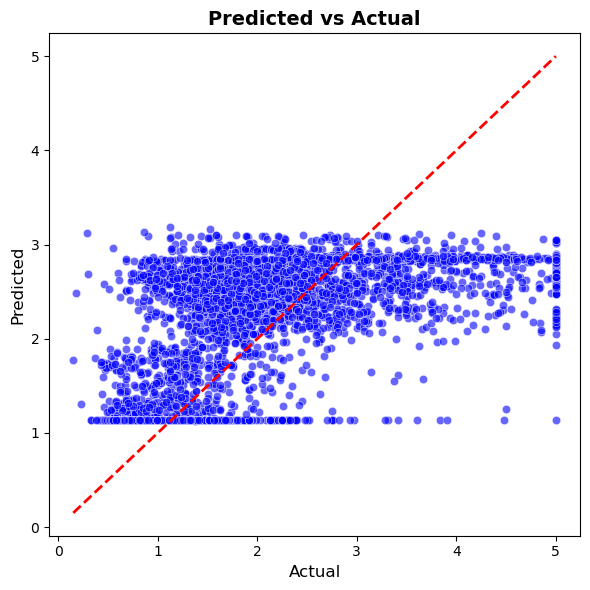


Epoch    36
Train_cost  = 0.9477 | Test_cost  = 0.9198 | Train_score = 0.2911 | Test_score = 0.2981 |
==> EarlyStop patience =  5 | Best test_score: 0.3187


─────────────────────────────────────────────────── 🚀 EPOCH 37 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1715.13it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9379 │ 0.8924 │
│ MAE    │ 0.7292 │ 0.7002 │
│ RMSE   │ 0.9684 │ 0.9447 │
│ R2     │ 0.2984 │ 0.3190 │
└────────┴────────┴────────┘

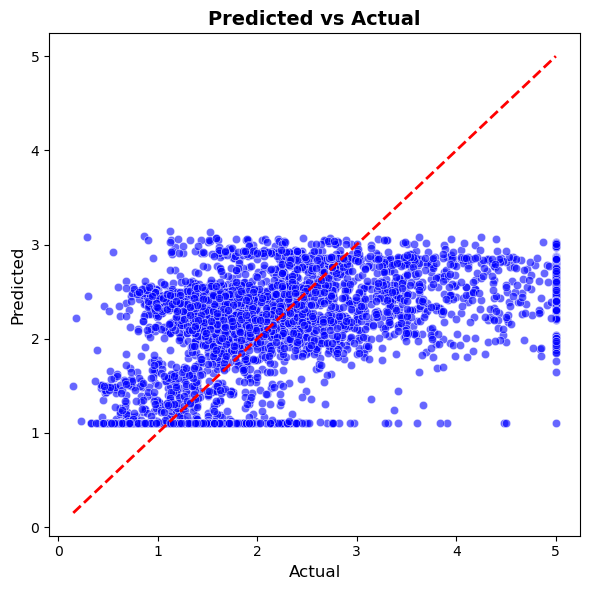


Epoch    37
Train_cost  = 0.9379 | Test_cost  = 0.8924 | Train_score = 0.2984 | Test_score = 0.3190 |


─────────────────────────────────────────────────── 🚀 EPOCH 38 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1734.19it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9463 │ 0.8943 │
│ MAE    │ 0.7330 │ 0.7201 │
│ RMSE   │ 0.9728 │ 0.9457 │
│ R2     │ 0.2921 │ 0.3175 │
└────────┴────────┴────────┘

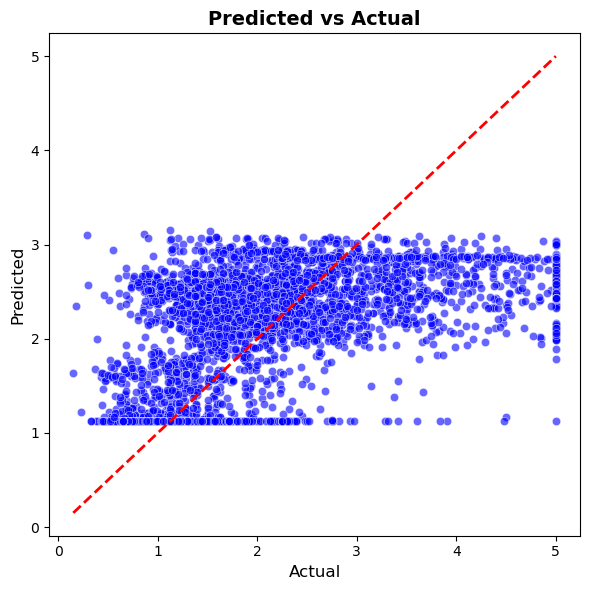


Epoch    38
Train_cost  = 0.9463 | Test_cost  = 0.8943 | Train_score = 0.2921 | Test_score = 0.3175 |
==> EarlyStop patience =  1 | Best test_score: 0.3190


─────────────────────────────────────────────────── 🚀 EPOCH 39 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1699.19it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9404 │ 0.8960 │
│ MAE    │ 0.7307 │ 0.6989 │
│ RMSE   │ 0.9697 │ 0.9466 │
│ R2     │ 0.2965 │ 0.3162 │
└────────┴────────┴────────┘

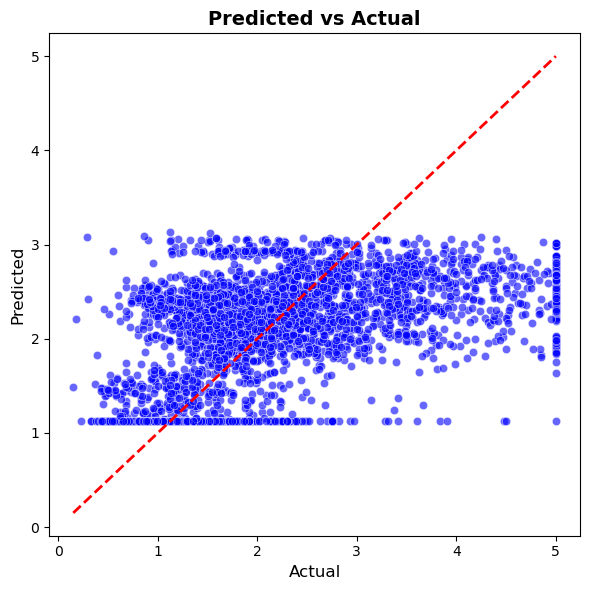


Epoch    39
Train_cost  = 0.9404 | Test_cost  = 0.8960 | Train_score = 0.2965 | Test_score = 0.3162 |
==> EarlyStop patience =  2 | Best test_score: 0.3190


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1703.66it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9440 │ 0.8889 │
│ MAE    │ 0.7327 │ 0.7078 │
│ RMSE   │ 0.9716 │ 0.9428 │
│ R2     │ 0.2938 │ 0.3216 │
└────────┴────────┴────────┘

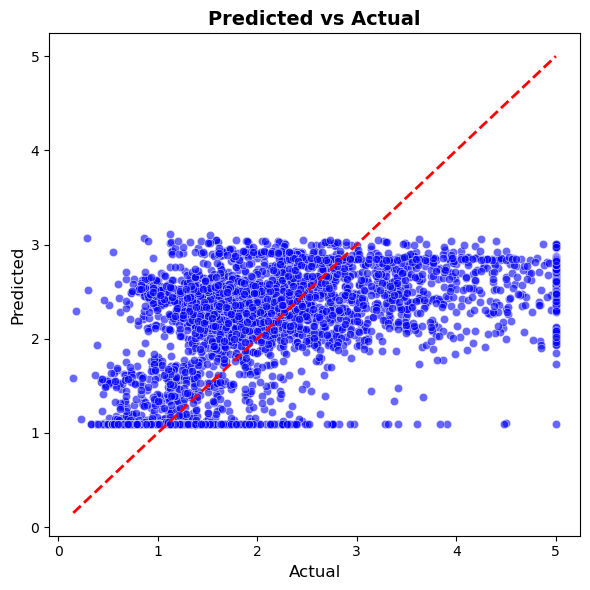


Epoch    40
Train_cost  = 0.9440 | Test_cost  = 0.8889 | Train_score = 0.2938 | Test_score = 0.3216 |


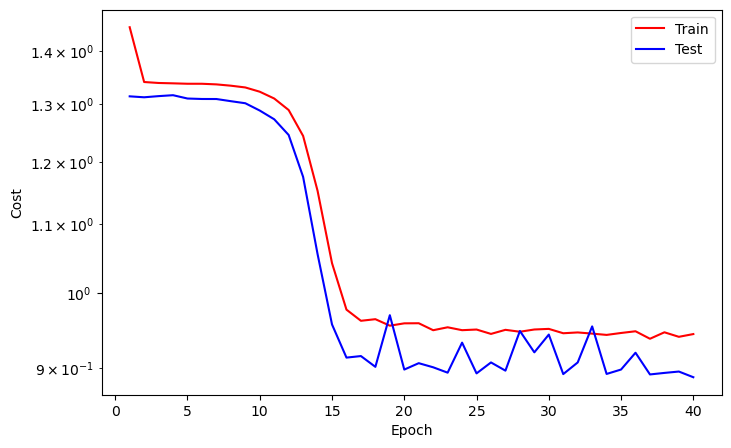

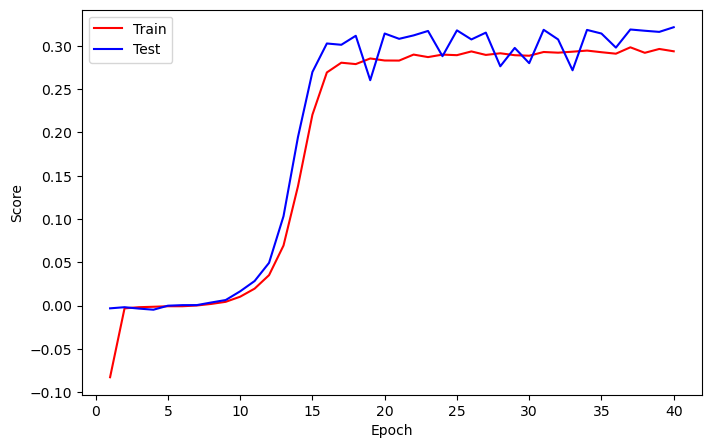

─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1699.11it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9446 │ 0.9340 │
│ MAE    │ 0.7329 │ 0.7601 │
│ RMSE   │ 0.9719 │ 0.9664 │
│ R2     │ 0.2934 │ 0.2872 │
└────────┴────────┴────────┘

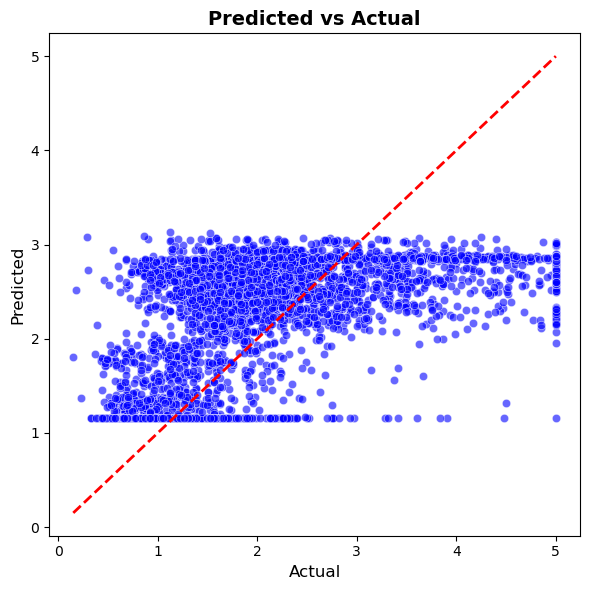


Epoch    41
Train_cost  = 0.9446 | Test_cost  = 0.9340 | Train_score = 0.2934 | Test_score = 0.2872 |
==> EarlyStop patience =  1 | Best test_score: 0.3216


─────────────────────────────────────────────────── 🚀 EPOCH 42 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1667.47it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9403 │ 0.8952 │
│ MAE    │ 0.7306 │ 0.7205 │
│ RMSE   │ 0.9697 │ 0.9462 │
│ R2     │ 0.2966 │ 0.3168 │
└────────┴────────┴────────┘

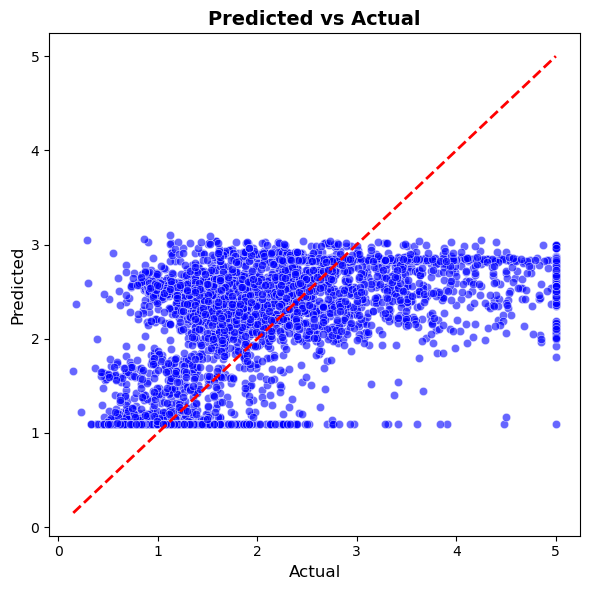


Epoch    42
Train_cost  = 0.9403 | Test_cost  = 0.8952 | Train_score = 0.2966 | Test_score = 0.3168 |
==> EarlyStop patience =  2 | Best test_score: 0.3216


─────────────────────────────────────────────────── 🚀 EPOCH 43 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1653.18it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9437 │ 0.8953 │
│ MAE    │ 0.7324 │ 0.7222 │
│ RMSE   │ 0.9715 │ 0.9462 │
│ R2     │ 0.2940 │ 0.3167 │
└────────┴────────┴────────┘

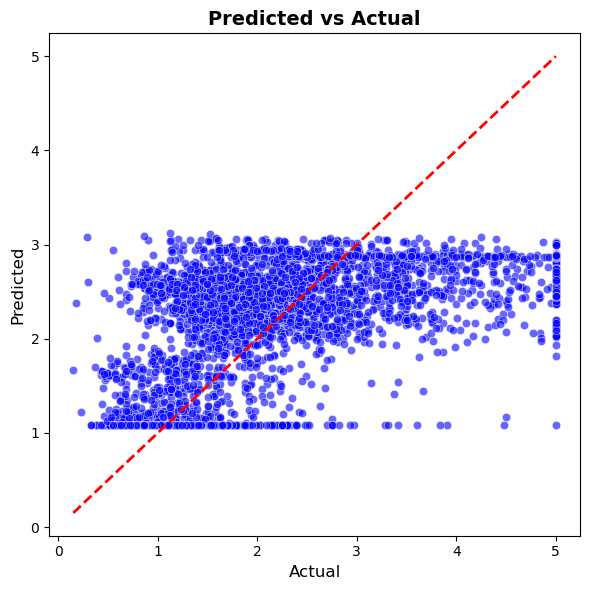


Epoch    43
Train_cost  = 0.9437 | Test_cost  = 0.8953 | Train_score = 0.2940 | Test_score = 0.3167 |
==> EarlyStop patience =  3 | Best test_score: 0.3216


─────────────────────────────────────────────────── 🚀 EPOCH 44 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1676.67it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9405 │ 0.8935 │
│ MAE    │ 0.7301 │ 0.7178 │
│ RMSE   │ 0.9698 │ 0.9453 │
│ R2     │ 0.2965 │ 0.3181 │
└────────┴────────┴────────┘

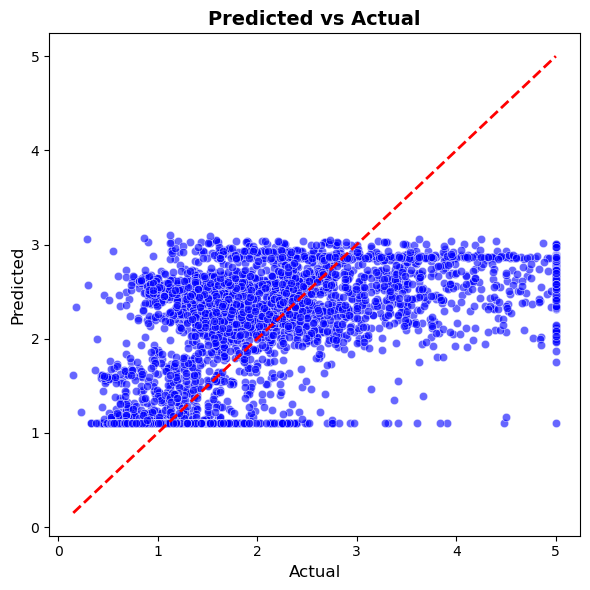


Epoch    44
Train_cost  = 0.9405 | Test_cost  = 0.8935 | Train_score = 0.2965 | Test_score = 0.3181 |
==> EarlyStop patience =  4 | Best test_score: 0.3216


─────────────────────────────────────────────────── 🚀 EPOCH 45 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1670.15it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9418 │ 0.8887 │
│ MAE    │ 0.7318 │ 0.7044 │
│ RMSE   │ 0.9705 │ 0.9427 │
│ R2     │ 0.2955 │ 0.3218 │
└────────┴────────┴────────┘

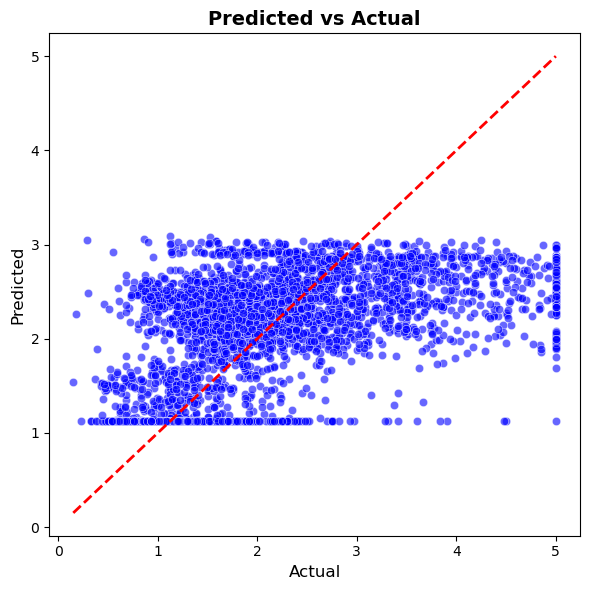


Epoch    45
Train_cost  = 0.9418 | Test_cost  = 0.8887 | Train_score = 0.2955 | Test_score = 0.3218 |


─────────────────────────────────────────────────── 🚀 EPOCH 46 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1697.16it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9373 │ 0.8935 │
│ MAE    │ 0.7295 │ 0.6978 │
│ RMSE   │ 0.9681 │ 0.9453 │
│ R2     │ 0.2988 │ 0.3181 │
└────────┴────────┴────────┘

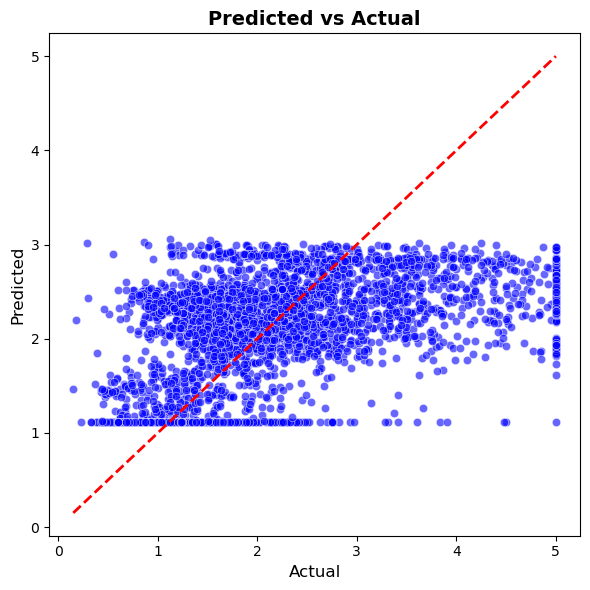


Epoch    46
Train_cost  = 0.9373 | Test_cost  = 0.8935 | Train_score = 0.2988 | Test_score = 0.3181 |
==> EarlyStop patience =  1 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 47 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1802.40it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9379 │ 0.9052 │
│ MAE    │ 0.7303 │ 0.7341 │
│ RMSE   │ 0.9685 │ 0.9514 │
│ R2     │ 0.2984 │ 0.3092 │
└────────┴────────┴────────┘

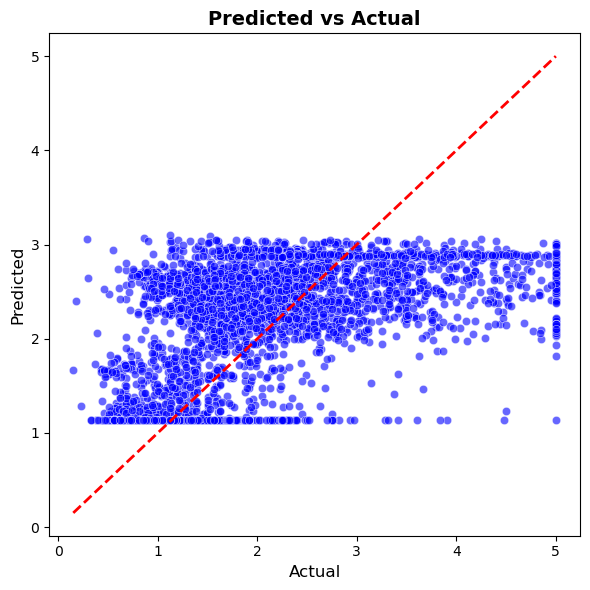


Epoch    47
Train_cost  = 0.9379 | Test_cost  = 0.9052 | Train_score = 0.2984 | Test_score = 0.3092 |
==> EarlyStop patience =  2 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 48 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1692.47it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9385 │ 0.8969 │
│ MAE    │ 0.7299 │ 0.7250 │
│ RMSE   │ 0.9688 │ 0.9471 │
│ R2     │ 0.2979 │ 0.3155 │
└────────┴────────┴────────┘

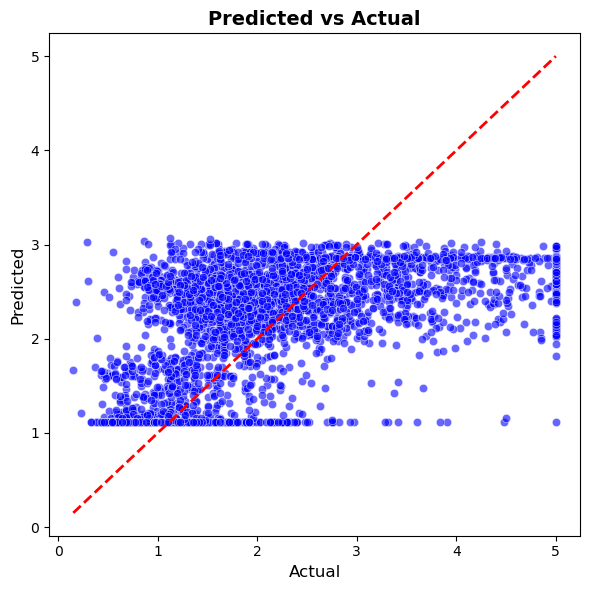


Epoch    48
Train_cost  = 0.9385 | Test_cost  = 0.8969 | Train_score = 0.2979 | Test_score = 0.3155 |
==> EarlyStop patience =  3 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 49 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1729.46it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9346 │ 0.9068 │
│ MAE    │ 0.7290 │ 0.7370 │
│ RMSE   │ 0.9668 │ 0.9523 │
│ R2     │ 0.3008 │ 0.3080 │
└────────┴────────┴────────┘

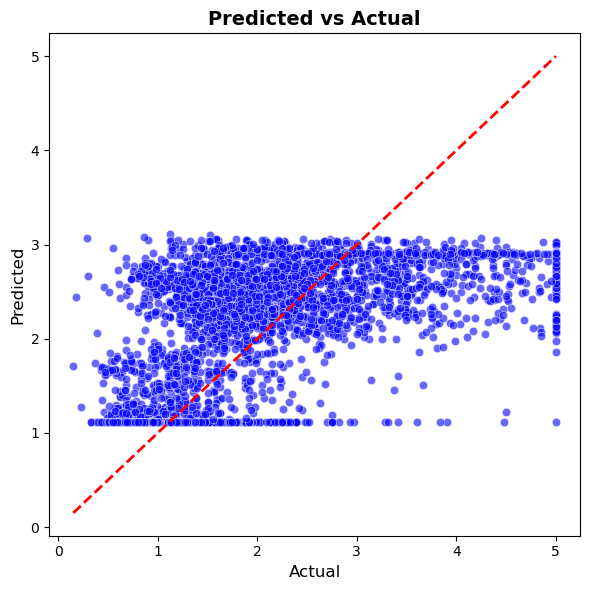


Epoch    49
Train_cost  = 0.9346 | Test_cost  = 0.9068 | Train_score = 0.3008 | Test_score = 0.3080 |
==> EarlyStop patience =  4 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 50 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1701.89it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9400 │ 0.8897 │
│ MAE    │ 0.7305 │ 0.6975 │
│ RMSE   │ 0.9695 │ 0.9432 │
│ R2     │ 0.2968 │ 0.3211 │
└────────┴────────┴────────┘

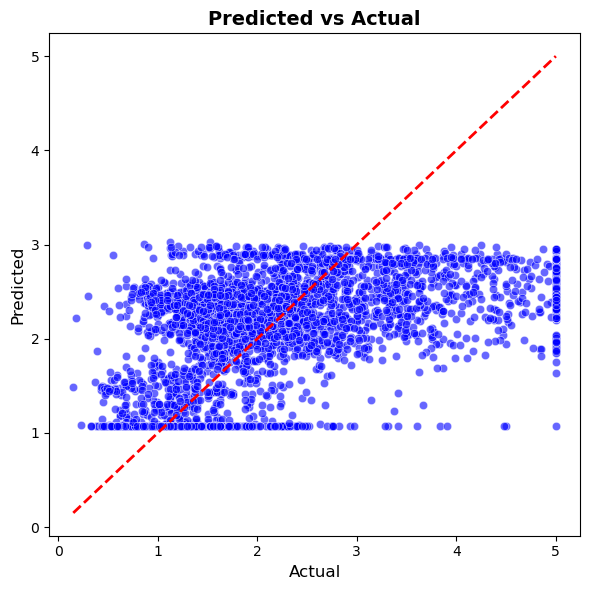


Epoch    50
Train_cost  = 0.9400 | Test_cost  = 0.8897 | Train_score = 0.2968 | Test_score = 0.3211 |
==> EarlyStop patience =  5 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 51 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1748.84it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9382 │ 0.9302 │
│ MAE    │ 0.7310 │ 0.7557 │
│ RMSE   │ 0.9686 │ 0.9645 │
│ R2     │ 0.2982 │ 0.2901 │
└────────┴────────┴────────┘

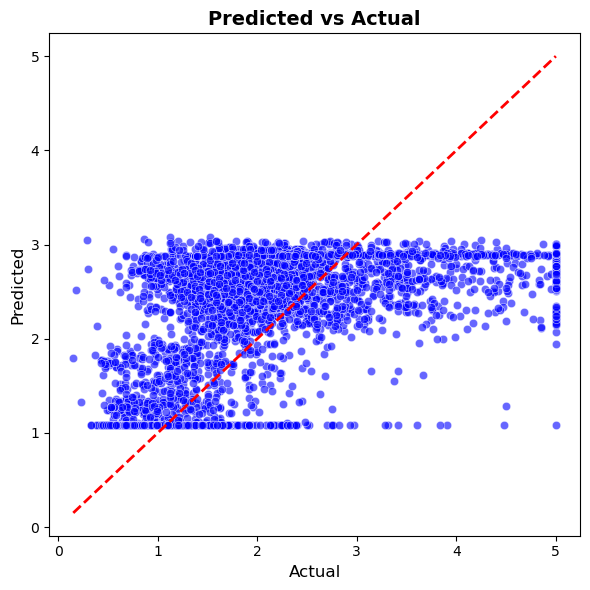


Epoch    51
Train_cost  = 0.9382 | Test_cost  = 0.9302 | Train_score = 0.2982 | Test_score = 0.2901 |
==> EarlyStop patience =  6 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 52 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1717.84it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9393 │ 0.9051 │
│ MAE    │ 0.7305 │ 0.7372 │
│ RMSE   │ 0.9692 │ 0.9514 │
│ R2     │ 0.2973 │ 0.3093 │
└────────┴────────┴────────┘

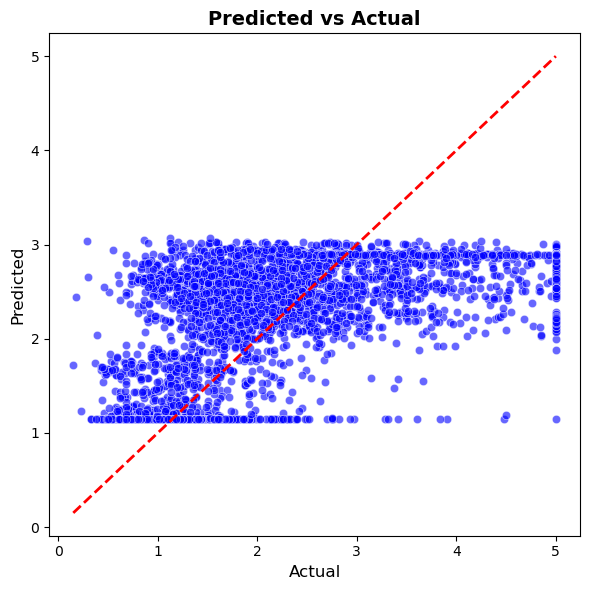


Epoch    52
Train_cost  = 0.9393 | Test_cost  = 0.9051 | Train_score = 0.2973 | Test_score = 0.3093 |
==> EarlyStop patience =  7 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 53 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1681.86it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9392 │ 0.9017 │
│ MAE    │ 0.7304 │ 0.6916 │
│ RMSE   │ 0.9691 │ 0.9496 │
│ R2     │ 0.2974 │ 0.3119 │
└────────┴────────┴────────┘

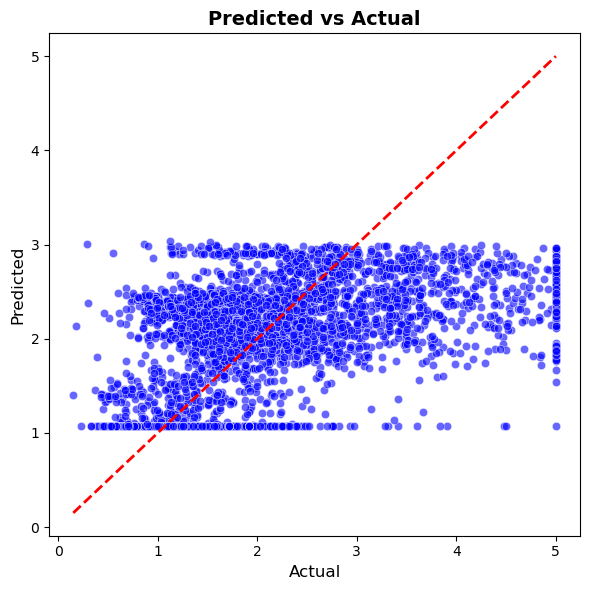


Epoch    53
Train_cost  = 0.9392 | Test_cost  = 0.9017 | Train_score = 0.2974 | Test_score = 0.3119 |
==> EarlyStop patience =  8 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 54 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1628.98it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9350 │ 0.9092 │
│ MAE    │ 0.7294 │ 0.6892 │
│ RMSE   │ 0.9669 │ 0.9535 │
│ R2     │ 0.3006 │ 0.3062 │
└────────┴────────┴────────┘

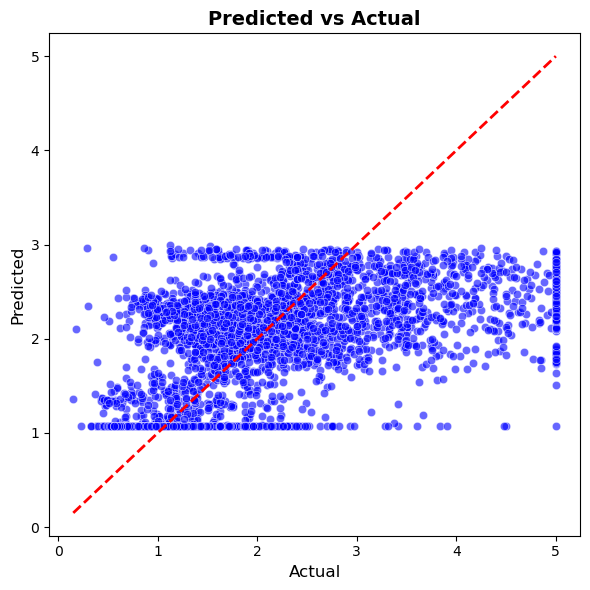


Epoch    54
Train_cost  = 0.9350 | Test_cost  = 0.9092 | Train_score = 0.3006 | Test_score = 0.3062 |
==> EarlyStop patience =  9 | Best test_score: 0.3218


─────────────────────────────────────────────────── 🚀 EPOCH 55 ───────────────────────────────────────────────────

test: 100%|██████████| 129/129 [00:00<00:00, 1634.75it/s]


    Summary (Regression)    
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃  Train ┃   Test ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ LOSS   │ 0.9362 │ 0.8974 │
│ MAE    │ 0.7288 │ 0.6918 │
│ RMSE   │ 0.9676 │ 0.9473 │
│ R2     │ 0.2996 │ 0.3151 │
└────────┴────────┴────────┘

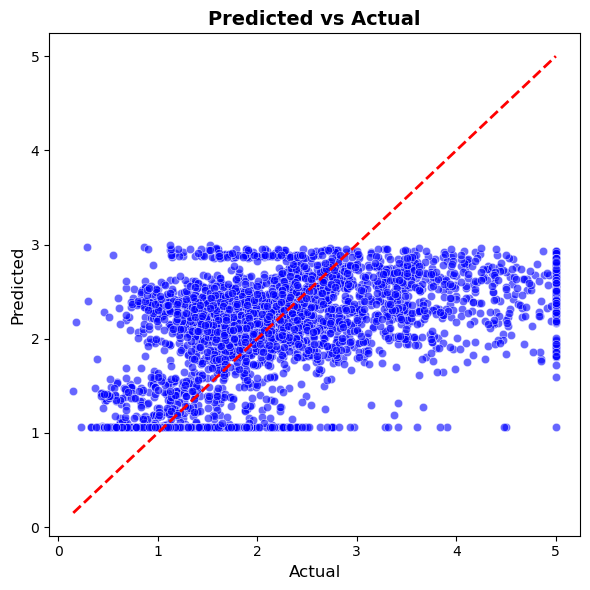


Epoch    55
Train_cost  = 0.9362 | Test_cost  = 0.8974 | Train_score = 0.2996 | Test_score = 0.3151 |
==> EarlyStop patience = 10 | Best test_score: 0.3218
==> Execute Early Stopping at epoch: 55 | Best test_score: 0.3218
==> Best model is saved at regresi/one-d/california_housing/


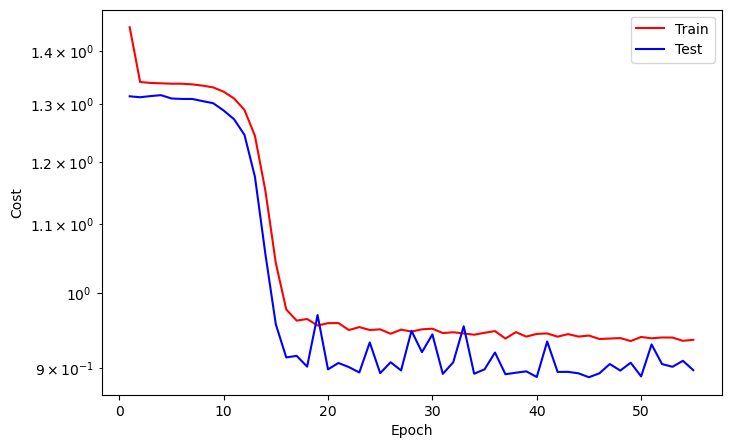

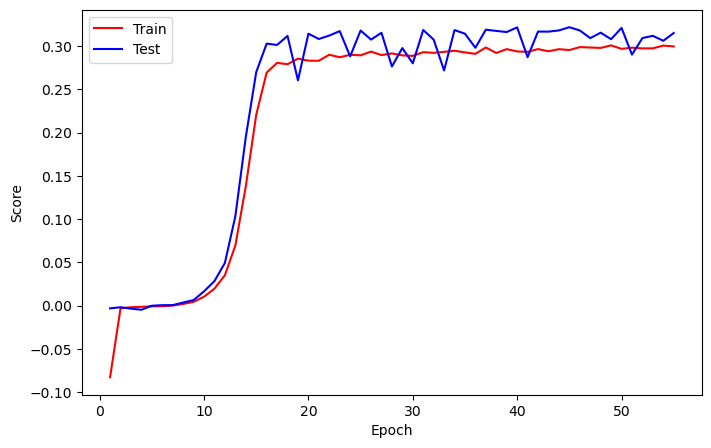

⏹️ Training dihentikan oleh early stopping.

In [30]:
from train_and_evaluate import train_and_evaluate_regression

train_and_evaluate_regression(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,        
    callback=callback,
    show_detail=True,
    dimension='2d'
)

# Evaluate

📊 Evaluasi Model Regresi 
┏━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Metrik        ┃  Nilai ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ 💥 Loss (avg) │ 0.8887 │
│ 📉 MAE        │ 0.7044 │
│ 📉 MSE        │ 0.8887 │
│ 📉 RMSE       │ 0.9427 │
│ 📈 R² Score   │ 0.3218 │
└───────────────┴────────┘

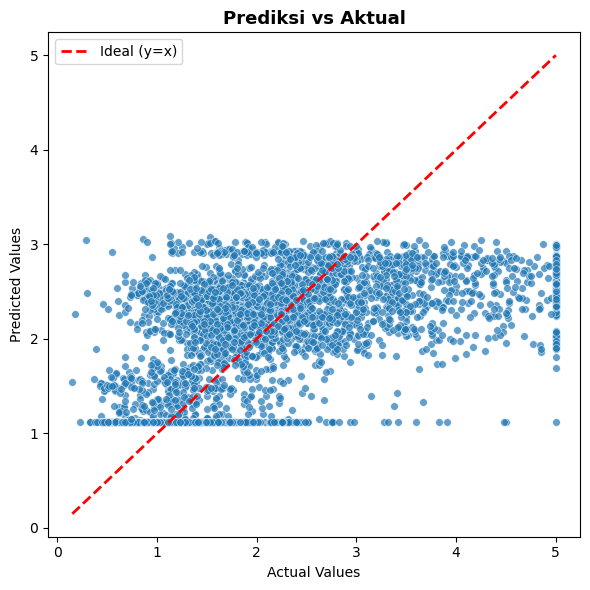

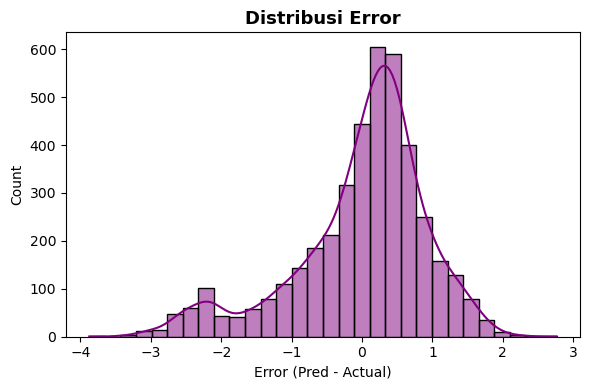

In [31]:
from evaluate import evaluate_regression

hsl = evaluate_regression(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    dimension='2d',
    
)

In [32]:
hsl['df'].head(200)

,Target,Prediksi,Error,Error (%)
0,2.317,1.1567,-1.1603,-50.080002
1,0.654,1.1252,0.4712,72.050003
2,1.332,1.1252,-0.2068,-15.530000
3,1.782,1.9173,0.1353,7.590000
4,1.953,2.9244,0.9714,49.740002
...,...,...,...,...
195,4.158,2.8625,-1.2955,-31.160000
196,1.514,3.0163,1.5023,99.220001
197,2.401,2.0221,-0.3789,-15.780000
198,0.887,2.0745,1.1875,133.869995


# Pengaplikasian

In [33]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension

In [34]:
import torch, json
from torch import optim, nn
from class_lib import Model2DPure
import joblib
import pandas as pd


# Load Config
try:
    config = torch.load(root_folder + "configs.pth", map_location="cpu", weights_only=False)
except:
    config = torch.load(root_folder + "configs.pth", map_location="cpu")

#Load Weights
weights= torch.load(root_folder + "weights_best.pth", map_location="cpu")


model = Model2DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    combined_dims= config.combine_dims,
    output_dim   = config.output_dim,
    dropout=config.dropout, 
    activation=config.activation
)
model.load_state_dict(weights)
model.eval() 

Model2DPure(
  (net1): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
  )
  (net2): Sequential(
    (0): Linear(in_features=4, out_features=3, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
  )
  (net_combined): Sequential(
    (0): Linear(in_features=5, out_features=3, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=3, out_features=1, bias=True)
  )
)

In [35]:
from aplokator import RegressionPredictor


predictor = RegressionPredictor(
    model=model,
    config=config,
    scaler_folder=root_folder,
    dimension='2d'
)

HTML(value='\n        <style>\n        .minimal-container { background: #f8f9fa; padding: 12px; border-radius:…